# Acceleration Magnitude Distribution Analysis

This notebook processes raw accelerometer data, standardizes units to g, and generates histograms of acceleration magnitude distributions.

**Analysis includes:**
1. Loading raw accelerometer data for all participants
2. Detecting and standardizing units (m/s² → g)
3. Computing average acceleration magnitudes at configurable time resolutions
4. Plotting magnitude and log-magnitude histograms for each subject


In [49]:
# Setup and imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Literal

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Define paths
PROJECT_ROOT = Path('/n/home01/egraff/sample_imputation')
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / 'g_units'
PLOTS_DIR = PROJECT_ROOT / 'plots'

# Create directories if they don't exist
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

# Standard gravity constant for unit conversion
STANDARD_GRAVITY = 9.80665  # m/s^2

# Discover subject IDs from raw data folder
SUBJECT_IDS = sorted(
    d.name for d in DATA_RAW.iterdir()
    if d.is_dir() and d.name != '__MACOSX'
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {DATA_RAW}")
print(f"Processed data directory: {DATA_PROCESSED}")
print(f"Plots directory: {PLOTS_DIR}")
print(f"\nFound {len(SUBJECT_IDS)} subjects: {', '.join(SUBJECT_IDS)}")


Project root: /n/home01/egraff/sample_imputation
Raw data directory: /n/home01/egraff/sample_imputation/data/raw
Processed data directory: /n/home01/egraff/sample_imputation/data/processed/g_units
Plots directory: /n/home01/egraff/sample_imputation/plots

Found 6 subjects: 3si9xdvl, bn4j8yj9, gq36edfi, ubrmuu2r, xwyd72l9, zg5uqa5l


## 1. Unit Detection and Standardization

Detect whether each subject's data is in m/s² (Android) or g (iOS) and standardize all to g units.


In [53]:
def detect_device_type(subject_id: str, data_raw: Path) -> str:
    """
    Detect device type (iOS or Android) based on folder structure.
    
    iOS devices have 'ios_log/' folder, Android devices have 'app_log/' folder.
    iOS reports acceleration in g units, Android in m/s².
    
    Parameters
    ----------
    subject_id : str
        Subject identifier
    data_raw : Path
        Path to raw data directory
        
    Returns
    -------
    str
        'ios' or 'android'
    """
    subject_dir = data_raw / subject_id
    if (subject_dir / 'ios_log').exists():
        return 'ios'
    elif (subject_dir / 'app_log').exists():
        return 'android'
    else:
        # Fallback: check accelerometer values
        # iOS values ~1, Android values ~9.8
        accel_dir = subject_dir / 'accelerometer'
        if accel_dir.exists():
            first_file = next(accel_dir.glob('*.csv'), None)
            if first_file:
                df = pd.read_csv(first_file, nrows=100)
                magnitude = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2).mean()
                return 'ios' if magnitude < 5 else 'android'
        raise ValueError(f"Cannot determine device type for {subject_id}")


def load_and_standardize_accelerometer(
    subject_id: str,
    data_raw: Path,
    data_processed: Path,
    standard_gravity: float = 9.80665
) -> pd.DataFrame:
    """
    Load raw accelerometer data, convert to g units if needed, and save to processed folder.
    
    Parameters
    ----------
    subject_id : str
        Subject identifier
    data_raw : Path
        Path to raw data directory
    data_processed : Path
        Path to processed data directory
    standard_gravity : float
        Standard gravity constant (m/s²)
        
    Returns
    -------
    pd.DataFrame
        Concatenated accelerometer data with columns: timestamp, x, y, z (in g units)
    """
    device_type = detect_device_type(subject_id, data_raw)
    accel_raw_dir = data_raw / subject_id / 'accelerometer'
    accel_processed_dir = data_processed / subject_id / 'accelerometer'
    accel_processed_dir.mkdir(parents=True, exist_ok=True)
    
    all_data = []
    csv_files = sorted(accel_raw_dir.glob('*.csv'))
    
    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        df['timestamp'] = pd.to_datetime(df['UTC time'], utc=True)
        
        # Convert to g units if Android (m/s² -> g)
        if device_type == 'android':
            df['x'] = df['x'] / standard_gravity
            df['y'] = df['y'] / standard_gravity
            df['z'] = df['z'] / standard_gravity
        
        # Keep only needed columns
        df = df[['timestamp', 'x', 'y', 'z']]
        
        # Save processed file
        output_file = accel_processed_dir / csv_file.name
        df.to_csv(output_file, index=False)
        
        all_data.append(df)
    
    if not all_data:
        return pd.DataFrame(columns=['timestamp', 'x', 'y', 'z'])
    
    combined = pd.concat(all_data, ignore_index=True).sort_values('timestamp')
    return combined


# Detect device types and process each subject
device_types = {}
processed_data = {}

for subject_id in SUBJECT_IDS:
    device_type = detect_device_type(subject_id, DATA_RAW)
    device_types[subject_id] = device_type
    print(f"{subject_id}: {device_type} ({'g units' if device_type == 'ios' else 'm/s² → g'})")

print(f"\nProcessing and standardizing accelerometer data...")
for subject_id in SUBJECT_IDS:
    print(f"\nProcessing {subject_id}...")
    df = load_and_standardize_accelerometer(
        subject_id, DATA_RAW, DATA_PROCESSED, STANDARD_GRAVITY
    )
    processed_data[subject_id] = df
    print(f"  Loaded {len(df):,} samples, saved to {DATA_PROCESSED / subject_id / 'accelerometer'}")

print(f"\n{'='*70}")
print(f"Standardized accelerometer data for {len(processed_data)} subjects")
print(f"All data now in g units, saved to: {DATA_PROCESSED}")
print(f"{'='*70}")


3si9xdvl: ios (g units)
bn4j8yj9: ios (g units)
gq36edfi: ios (g units)
ubrmuu2r: android (m/s² → g)
xwyd72l9: android (m/s² → g)
zg5uqa5l: ios (g units)

Processing and standardizing accelerometer data...

Processing 3si9xdvl...
  Loaded 1,187,679 samples, saved to /n/home01/egraff/sample_imputation/data/processed/g_units/3si9xdvl/accelerometer

Processing bn4j8yj9...
  Loaded 1,949,079 samples, saved to /n/home01/egraff/sample_imputation/data/processed/g_units/bn4j8yj9/accelerometer

Processing gq36edfi...
  Loaded 1,686,751 samples, saved to /n/home01/egraff/sample_imputation/data/processed/g_units/gq36edfi/accelerometer

Processing ubrmuu2r...
  Loaded 4,851,842 samples, saved to /n/home01/egraff/sample_imputation/data/processed/g_units/ubrmuu2r/accelerometer

Processing xwyd72l9...
  Loaded 3,072,965 samples, saved to /n/home01/egraff/sample_imputation/data/processed/g_units/xwyd72l9/accelerometer

Processing zg5uqa5l...
  Loaded 2,307,051 samples, saved to /n/home01/egraff/sample

In [ ]:

# Call processed data from /data/processed/g_units/
processed_data = pd.read_csv(DATA_PROCESSED / 'processed_data.csv')

# Display summary of processed data
summary_data = []

for subject_id in SUBJECT_IDS:
    df = processed_data[subject_id]
    if len(df) > 0:
        # Compute magnitude and subtract 1g for gravity
        magnitude = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2) - 1.0
        summary_data.append({
            'Subject': subject_id,
            'Device': device_types[subject_id],
            'Samples': len(df),
            'Mean |a|-1g': magnitude.mean(),
            'Std |a|-1g': magnitude.std(),
            'Time Range': f"{df['timestamp'].min().strftime('%Y-%m-%d')} to {df['timestamp'].max().strftime('%Y-%m-%d')}"
        })

summary_df = pd.DataFrame(summary_data)
print("\nProcessed Data Summary (magnitude with gravity subtracted):")
print(summary_df.to_string(index=False))





FileNotFoundError: [Errno 2] No such file or directory: '/n/home01/egraff/sample_imputation/data/processed/g_units/processed_data.csv'

## 2. Flexible Histogram Function

Create a reusable function for plotting acceleration magnitude histograms with configurable:
- Linear or log scale (with configurable base)
- Time resolution (minute, hour, day with custom counts)
- Histogram bin size


In [ ]:
# Valid bin methods from numpy.histogram_bin_edges
BIN_METHODS = ['auto', 'fd', 'doane', 'scott', 'stone', 'rice', 'sturges', 'sqrt']

def plot_magnitude_histogram(
    data: pd.DataFrame,
    subject_id: str,
    use_log: bool = False,
    log_base: float = 10,
    log_counts: bool = False,
    resolution: Literal['minute', 'hour', 'day'] = 'minute',
    resolution_count: int = 1,
    bins: int | None = None,
    bin_method: str = 'fd',
    ax: plt.Axes | None = None,
    save_path: Path | None = None
) -> plt.Figure:
    """
    Plot histogram of acceleration magnitudes at specified time resolution.
    
    Parameters
    ----------
    data : pd.DataFrame
        DataFrame with columns: timestamp, x, y, z (acceleration in g units)
    subject_id : str
        Subject identifier (for plot title)
    use_log : bool, default False
        If True, plot log of magnitude instead of raw magnitude (x-axis)
    log_base : float, default 10
        Base for logarithm (e.g., 10 for log10, np.e for natural log)
    log_counts : bool, default False
        If True, use log scale for y-axis (counts)
    resolution : {'minute', 'hour', 'day'}, default 'minute'
        Time resolution for averaging
    resolution_count : int, default 1
        Number of resolution units (e.g., 3 for "3 hours")
    bins : int or None, default None
        Number of histogram bins. Overrides bin_method if provided.
    bin_method : str, default 'fd'
        Method for computing bin edges. Uses numpy.histogram_bin_edges.
        Options: 'auto', 'fd', 'doane', 'scott', 'stone', 'rice', 'sturges', 'sqrt'
        - 'auto': Minimum of 'sturges' and 'fd' (good default)
        - 'fd': Freedman-Diaconis (robust to outliers)
        - 'doane': Improved Sturges for non-normal data
        - 'scott': Based on standard deviation
        - 'stone': Cross-validation based
        - 'rice': Simple cube root rule
        - 'sturges': Log-based (R's default)
        - 'sqrt': Square root rule
    ax : plt.Axes or None, default None
        Axes to plot on. If None, creates new figure.
    save_path : Path or None, default None
        If provided, saves figure to this path.
        
    Returns
    -------
    plt.Figure
        The matplotlib figure object
    """
    df = data.copy()

    
    # Build pandas frequency string
    freq_map = {'minute': 'min', 'hour': 'h', 'day': 'D'}
    freq_str = f'{resolution_count}{freq_map[resolution]}'
    
    # Set timestamp as index for resampling
    df = df.set_index('timestamp')
    
    # Resample to specified resolution, taking mean of magnitudes
    resampled = df['magnitude'].resample(freq_str).mean().dropna()
    
    if len(resampled) == 0:
        raise ValueError(f"No data after resampling at {resolution_count} {resolution}(s)")
    
    # Apply log transform to x-axis values if requested
    if use_log:
        # Filter out zero/negative values before log
        resampled = resampled[resampled > 0]
        if log_base == np.e:
            values = np.log(resampled)
            log_label = 'ln'
        elif log_base == 10:
            values = np.log10(resampled)
            log_label = 'log₁₀'
        elif log_base == 2:
            values = np.log2(resampled)
            log_label = 'log₂'
        else:
            values = np.log(resampled) / np.log(log_base)
            log_label = f'log_{log_base:.1f}'
        x_label = '|a| - 1g (g) [log scale]'
    else:
        values = resampled
        x_label = '|a| - 1g (g)'
    
    # Create figure if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.get_figure()
    
    # Compute bin edges using numpy's histogram_bin_edges
    if bins is not None:
        # Use explicit bin count if provided
        computed_bin_edges = np.histogram_bin_edges(values, bins=bins)
        used_method = f'{bins} bins'
    else:
        # Use bin method string
        if bin_method not in BIN_METHODS:
            raise ValueError(f"bin_method must be one of {BIN_METHODS}, got '{bin_method}'")
        computed_bin_edges = np.histogram_bin_edges(values, bins=bin_method)
        used_method = bin_method
    
    # Plot histogram and capture bin information
    hist_kwargs = {'edgecolor': 'black', 'alpha': 0.7, 'color': 'steelblue'}
    hist_kwargs['bins'] = computed_bin_edges
    
    counts, bin_edges, patches = ax.hist(values, **hist_kwargs)
    
    # Calculate bin width
    bin_width = bin_edges[1] - bin_edges[0]
    n_bins = len(bin_edges) - 1
    
    # Set x-axis ticks to show bin edges (show subset if too many)
    # If use_log, convert bin edges back to original scale for labels
    if use_log:
        if log_base == np.e:
            original_bin_edges = np.exp(bin_edges)
        else:
            original_bin_edges = log_base ** bin_edges
    else:
        original_bin_edges = bin_edges
    
    if n_bins <= 15:
        # Show all bin edges
        ax.set_xticks(bin_edges)
        ax.set_xticklabels([f'{edge:.3g}' for edge in original_bin_edges], rotation=45, ha='right')
    else:
        # Show approximately 10 evenly spaced bin edges
        step = max(1, n_bins // 10)
        tick_indices = list(range(0, len(bin_edges), step))
        if tick_indices[-1] != len(bin_edges) - 1:
            tick_indices.append(len(bin_edges) - 1)
        ax.set_xticks([bin_edges[i] for i in tick_indices])
        ax.set_xticklabels([f'{original_bin_edges[i]:.3g}' for i in tick_indices], rotation=45, ha='right')
    
    # Apply log scale to y-axis if requested
    if log_counts:
        ax.set_yscale('log')
        y_label = 'Frequency (log counts)'
    else:
        y_label = 'Frequency (counts)'
    
    # Labels and title
    resolution_label = f'{resolution_count} {resolution}' if resolution_count > 1 else resolution
    title = f'{subject_id}: Acceleration Magnitude Distribution ({resolution_label} averages)'
    if use_log:
        title += f' [x: {log_label}]'
    if log_counts:
        title += ' [y: log]'
    
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add stats annotation with bin info
    stats_text = (
        f'N = {len(values):,}\n'
        f'Mean = {values.mean():.3f}\n'
        f'Std = {values.std():.3f}\n'
        f'Method = {used_method}\n'
        f'Bins = {n_bins}\n'
        f'Bin width = {bin_width:.4f}'
    )
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved histogram to {save_path}")
    
    return fig


In [ ]:
# Test the histogram function with a single subject
test_subject = SUBJECT_IDS[0]
print(f"Testing histogram function with subject: {test_subject}")

# Linear x, linear y (default)
print("\n1. Linear magnitude (x) + Linear counts (y)")
fig = plot_magnitude_histogram(
    processed_data[test_subject],
    test_subject,
    use_log=False,
    log_counts=False,
    resolution='minute',
    resolution_count=1
)
plt.show()

# Test 3: Linear x, log y
print("\n3. Linear magnitude (x) + Log counts (y)")
fig = plot_magnitude_histogram(
    processed_data[test_subject],
    test_subject,
    use_log=False,
    log_counts=True,
    resolution='minute',
    resolution_count=1
)
plt.show()


Testing histogram function with subject: 3si9xdvl

1. Linear magnitude (x) + Linear counts (y)


KeyError: 'magnitude'

## 3. Generate Histograms for All Subjects

Plot magnitude and log-magnitude histograms for each subject at minutely resolution.


Generating magnitude histograms ( scale, fd bins)...

3si9xdvl:
  Saved histogram to /n/home01/egraff/sample_imputation/plots/3si9xdvl_magnitude_histogram.png


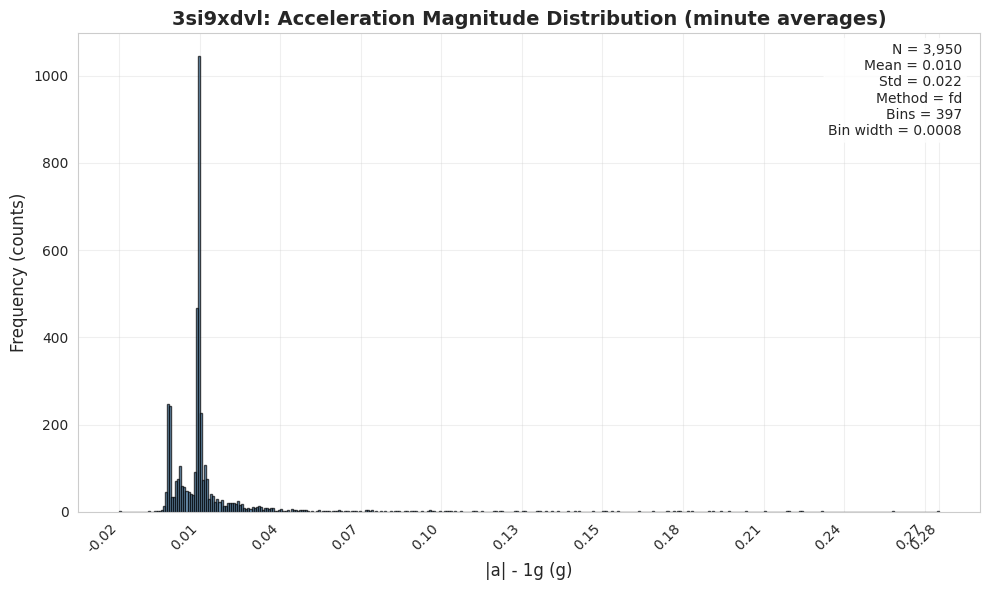


bn4j8yj9:
  Saved histogram to /n/home01/egraff/sample_imputation/plots/bn4j8yj9_magnitude_histogram.png


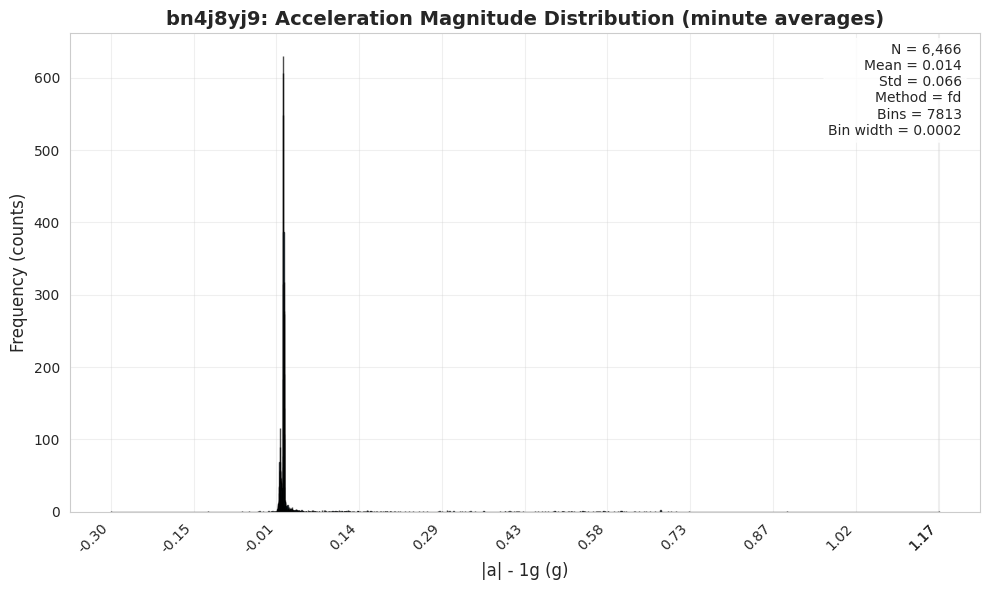


gq36edfi:
  Saved histogram to /n/home01/egraff/sample_imputation/plots/gq36edfi_magnitude_histogram.png


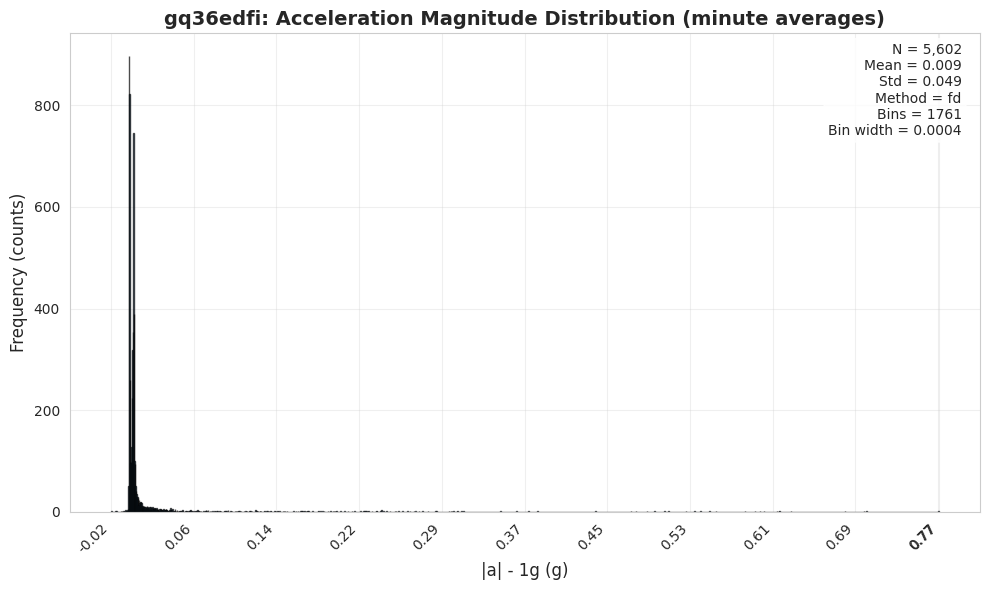


ubrmuu2r:
  Saved histogram to /n/home01/egraff/sample_imputation/plots/ubrmuu2r_magnitude_histogram.png


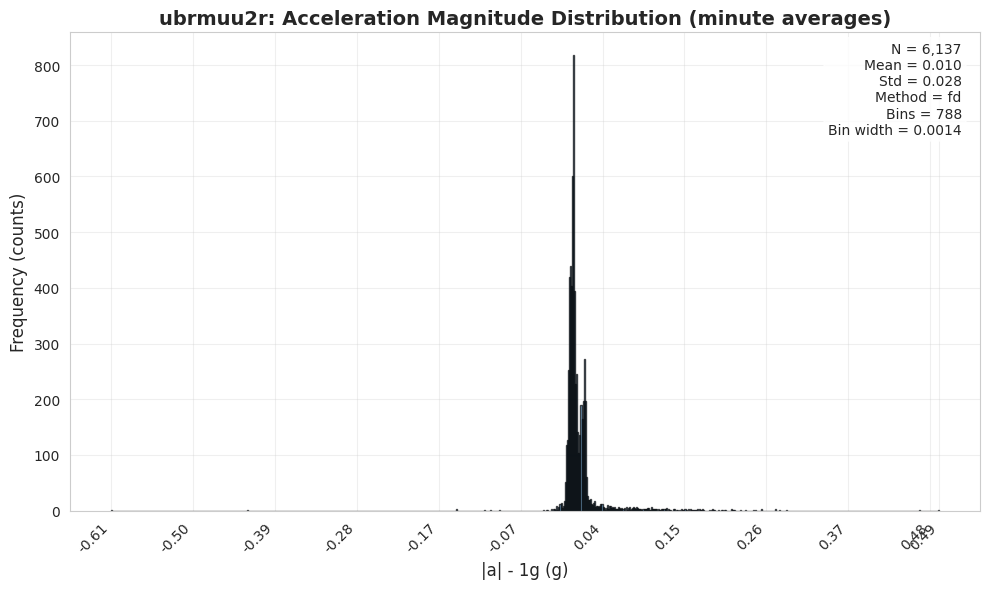


xwyd72l9:
  Saved histogram to /n/home01/egraff/sample_imputation/plots/xwyd72l9_magnitude_histogram.png


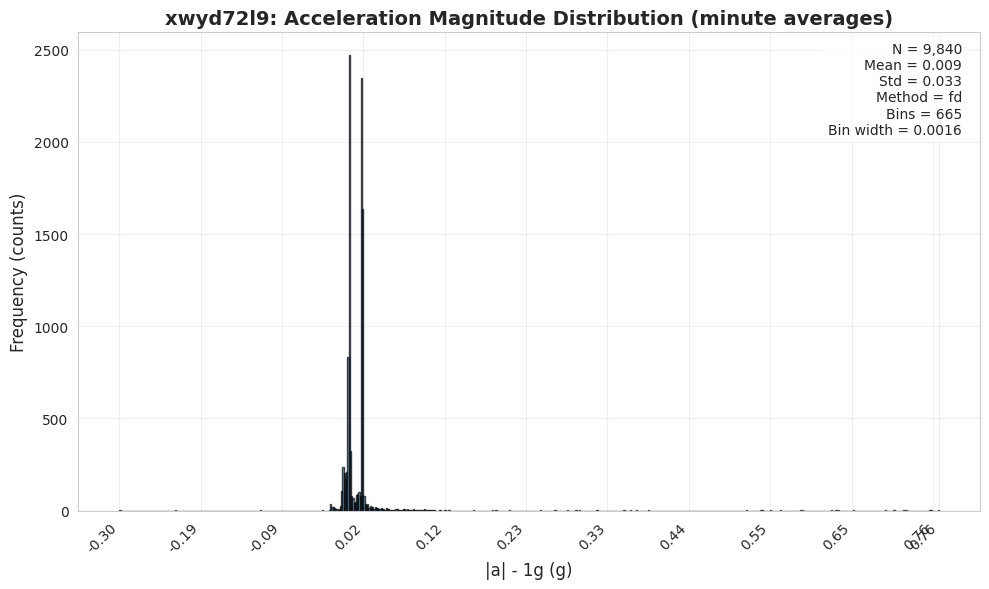


zg5uqa5l:
  Saved histogram to /n/home01/egraff/sample_imputation/plots/zg5uqa5l_magnitude_histogram.png


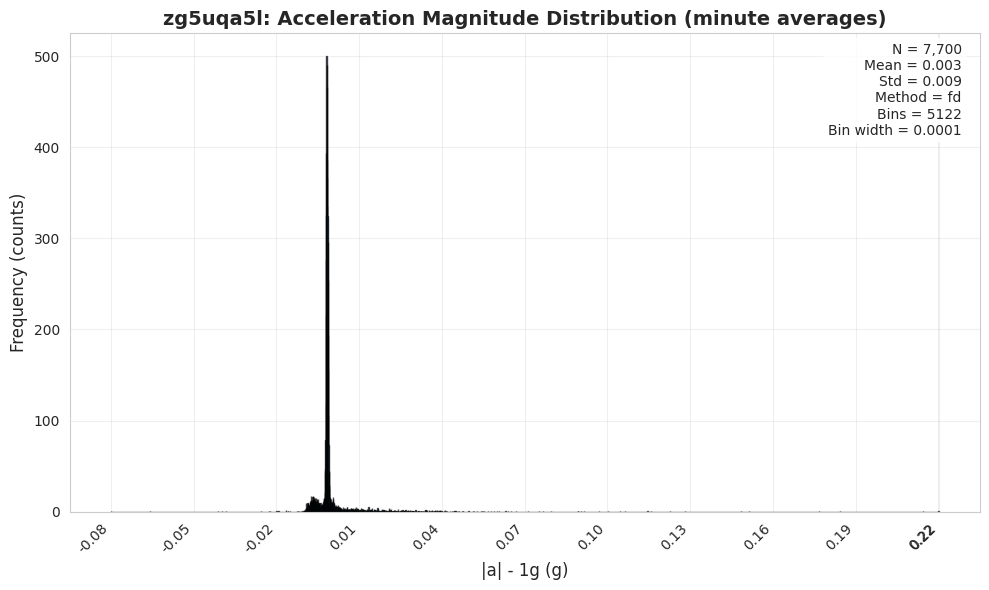


Generated magnitude histograms for 6 subjects


In [ ]:
# Generate magnitude histograms for all subjects (minutely, linear scale, default fd bins)
print("Generating magnitude histograms ( scale, fd bins)...")
print("="*70)

for subject_id in SUBJECT_IDS:
    print(f"\n{subject_id}:")
    save_path = PLOTS_DIR / f"{subject_id}_magnitude_histogram.png"
    fig = plot_magnitude_histogram(
        processed_data[subject_id],
        subject_id,
        use_log=False,
        resolution='minute',
        resolution_count=1,
        bin_method='fd',
        save_path=save_path
    )
    plt.show()
    plt.close(fig)

print(f"\n{'='*70}")
print(f"Generated magnitude histograms for {len(SUBJECT_IDS)} subjects")
print(f"{'='*70}")


Generating histograms of log magnitude for all bin methods...

Bin method: auto

3si9xdvl (auto):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/3si9xdvl_auto_logcounts_histogram.png


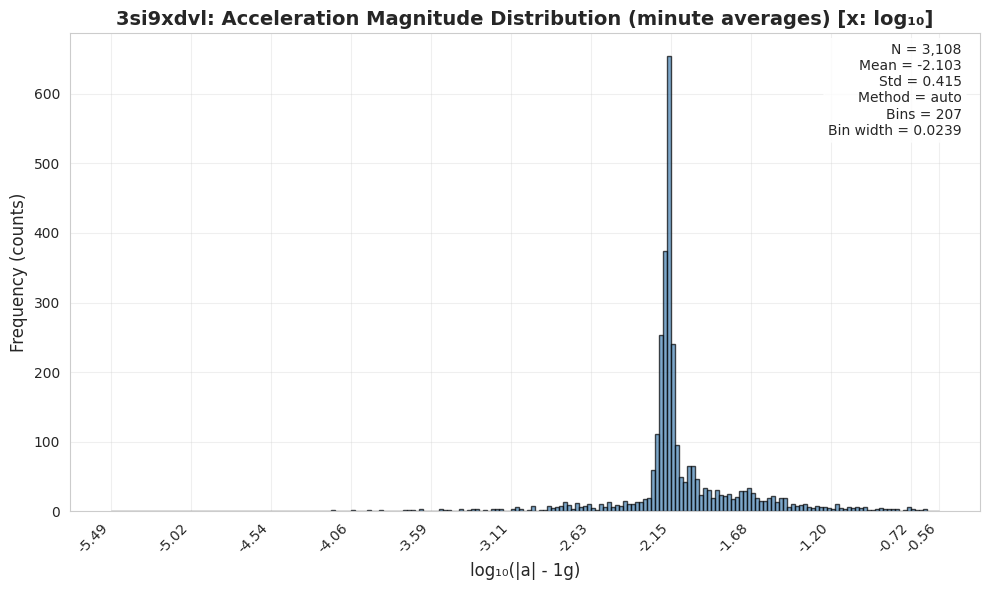


bn4j8yj9 (auto):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/bn4j8yj9_auto_logcounts_histogram.png


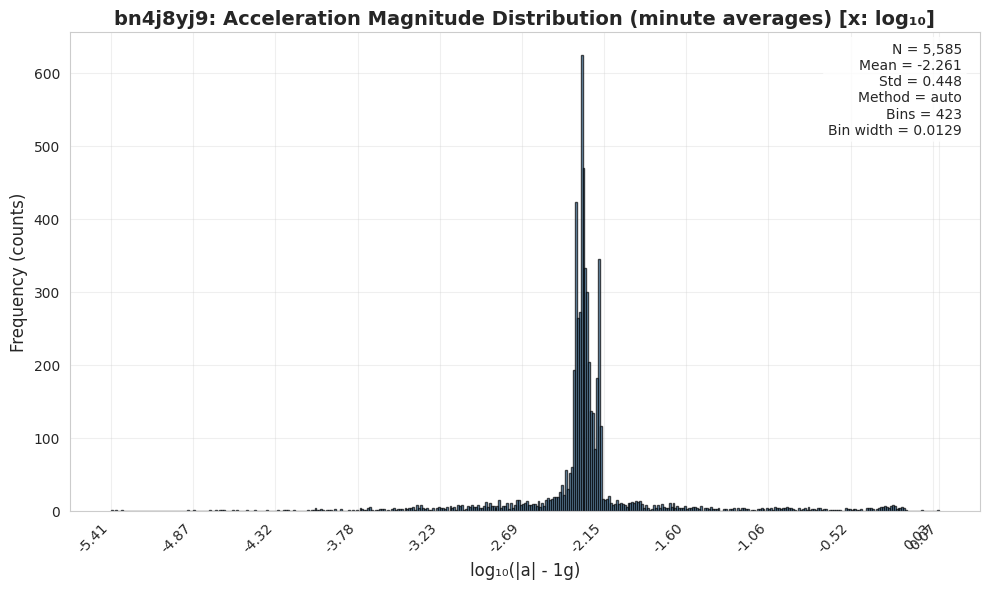


gq36edfi (auto):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/gq36edfi_auto_logcounts_histogram.png


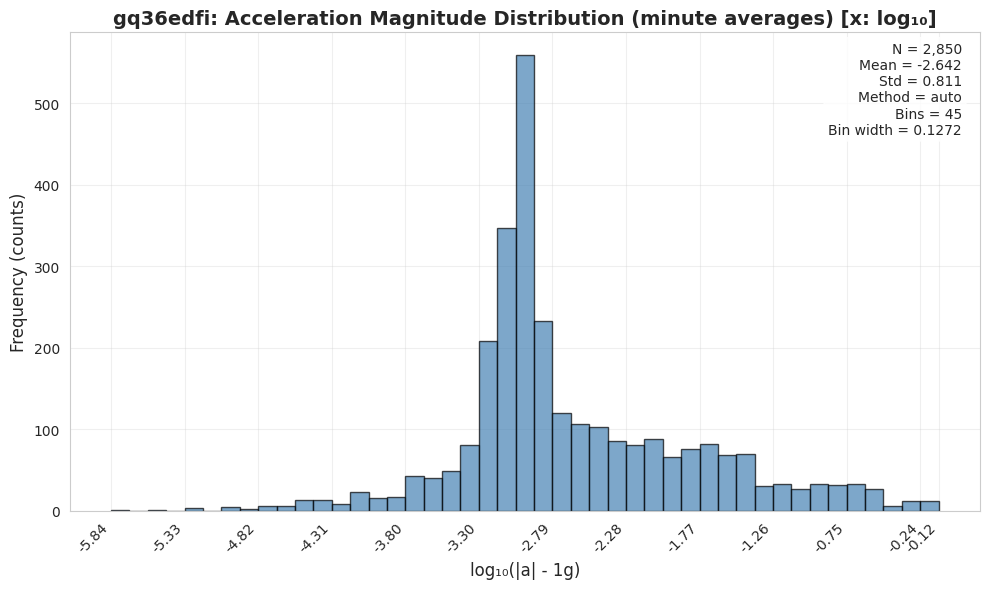


ubrmuu2r (auto):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/ubrmuu2r_auto_logcounts_histogram.png


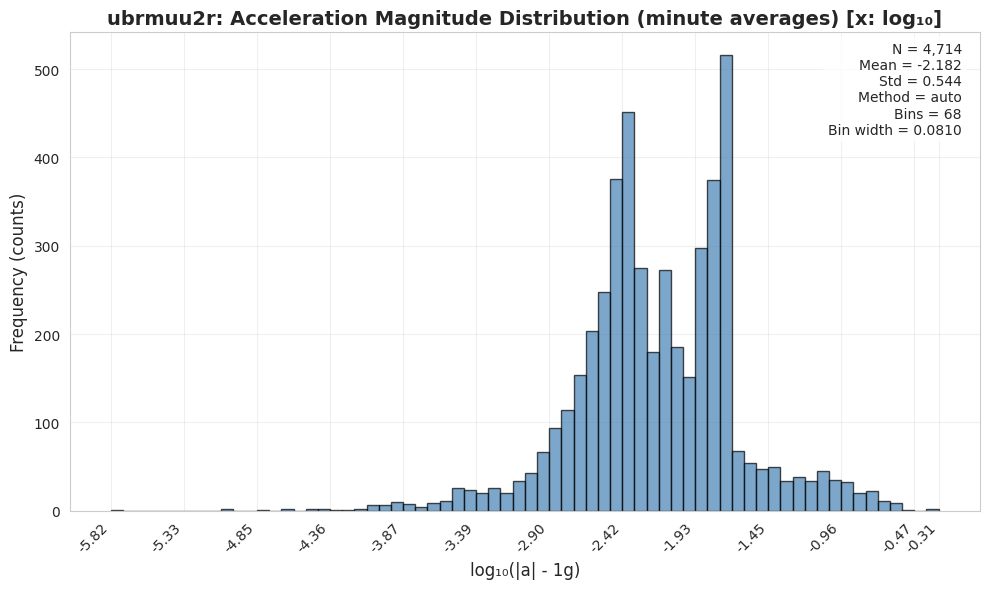


xwyd72l9 (auto):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/xwyd72l9_auto_logcounts_histogram.png


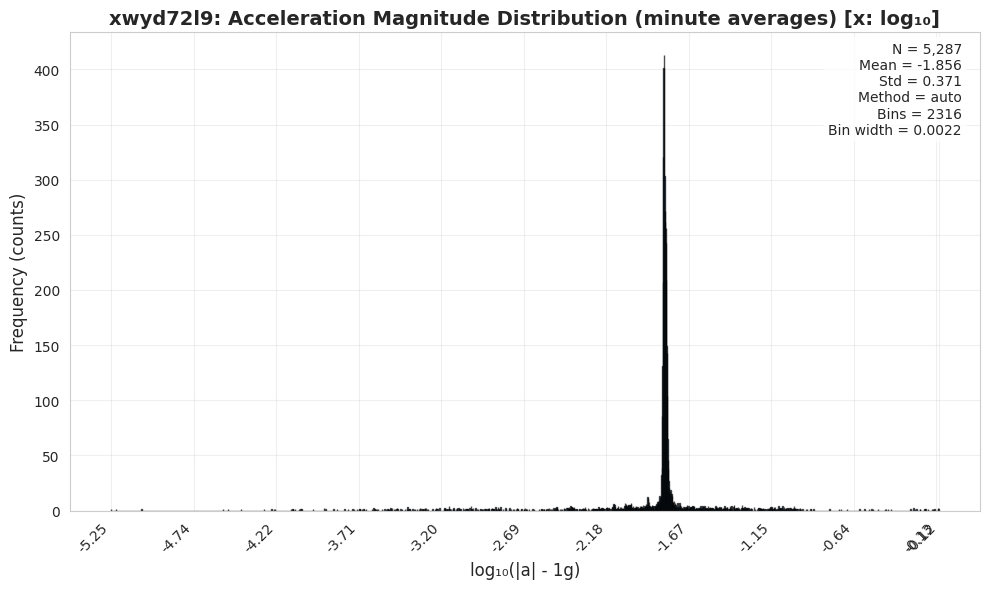


zg5uqa5l (auto):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/zg5uqa5l_auto_logcounts_histogram.png


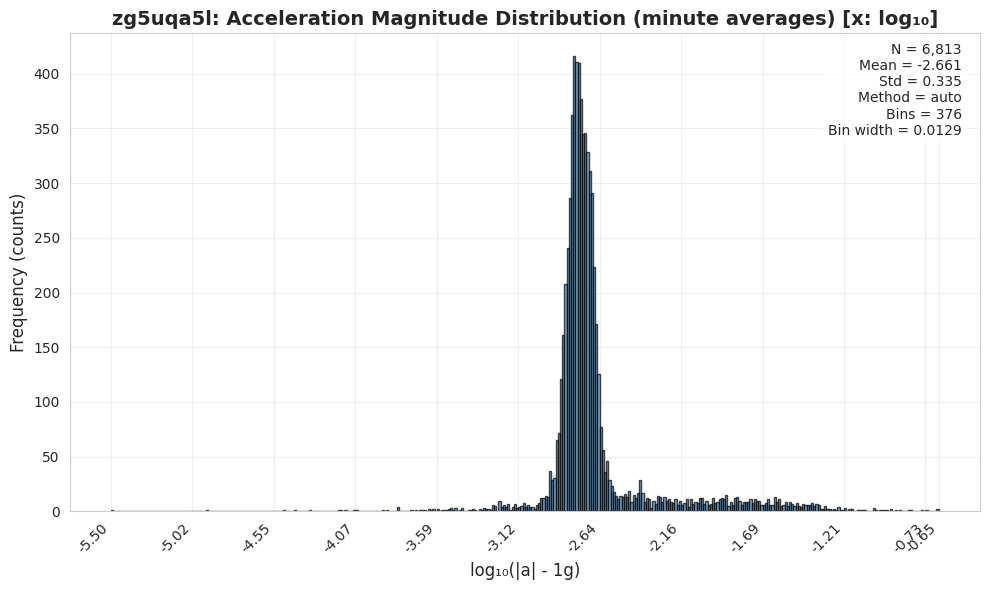


Bin method: fd

3si9xdvl (fd):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/3si9xdvl_fd_logcounts_histogram.png


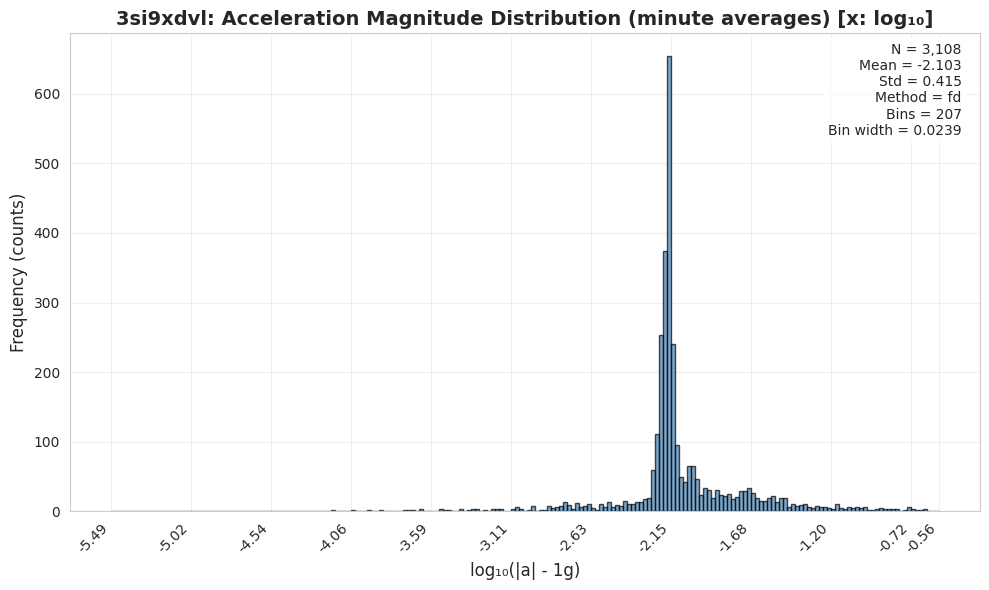


bn4j8yj9 (fd):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/bn4j8yj9_fd_logcounts_histogram.png


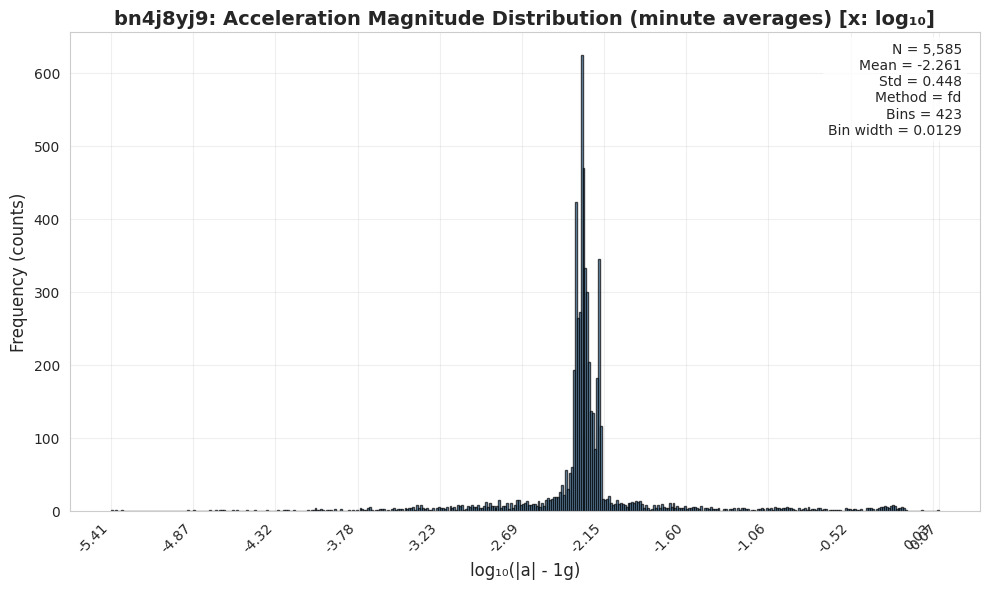


gq36edfi (fd):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/gq36edfi_fd_logcounts_histogram.png


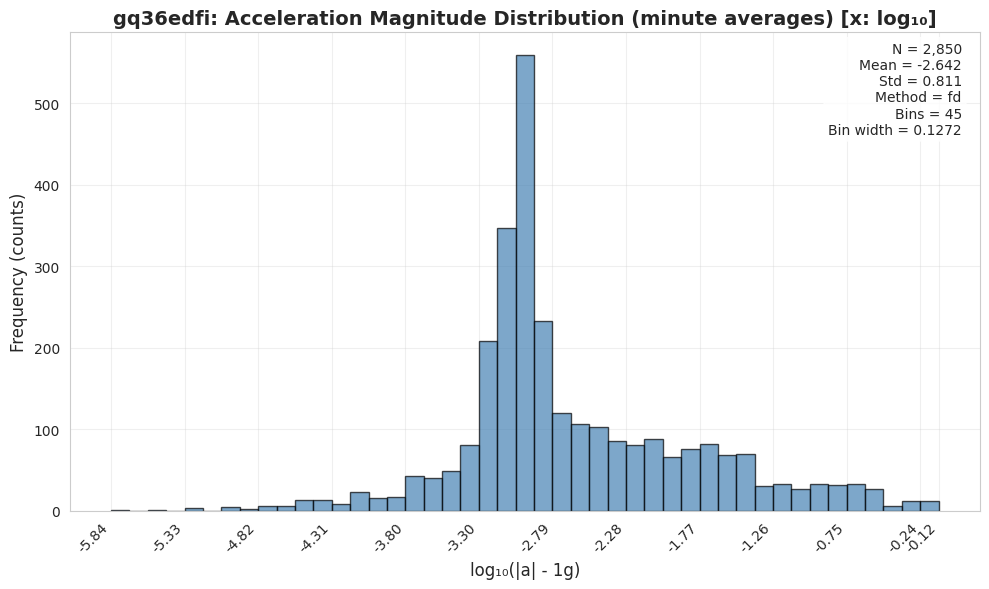


ubrmuu2r (fd):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/ubrmuu2r_fd_logcounts_histogram.png


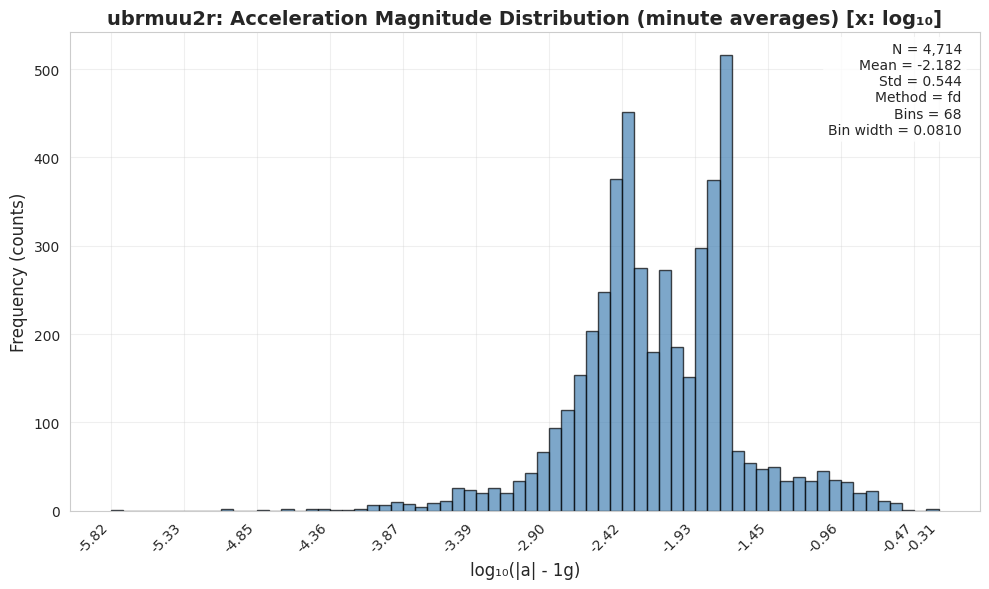


xwyd72l9 (fd):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/xwyd72l9_fd_logcounts_histogram.png


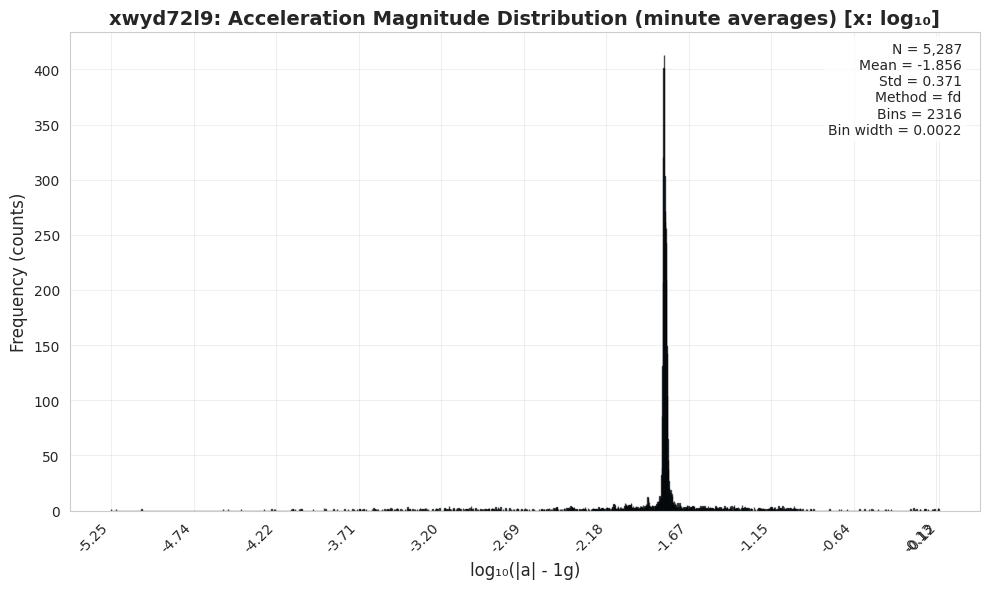


zg5uqa5l (fd):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/zg5uqa5l_fd_logcounts_histogram.png


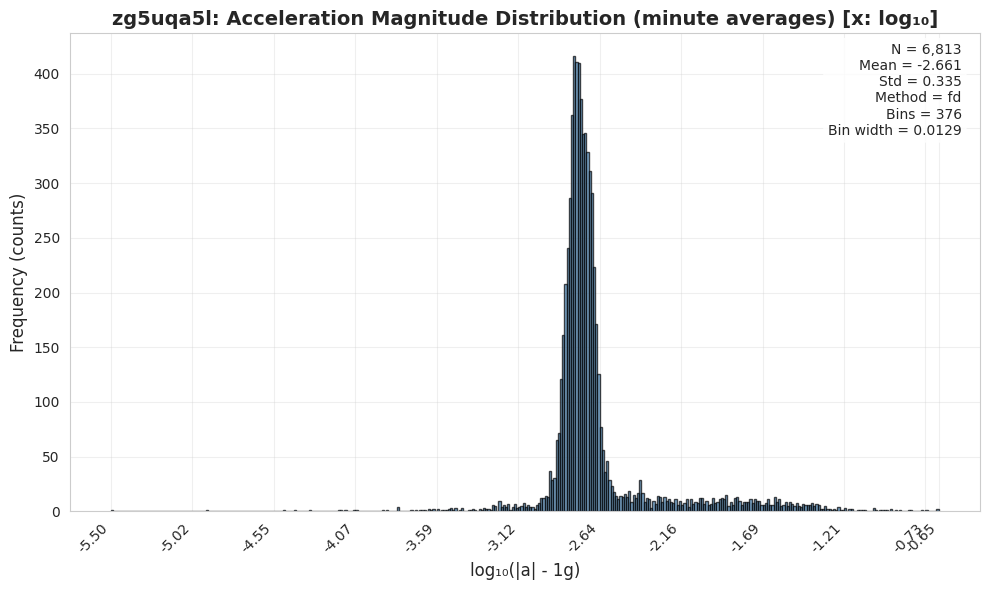


Bin method: doane

3si9xdvl (doane):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/3si9xdvl_doane_logcounts_histogram.png


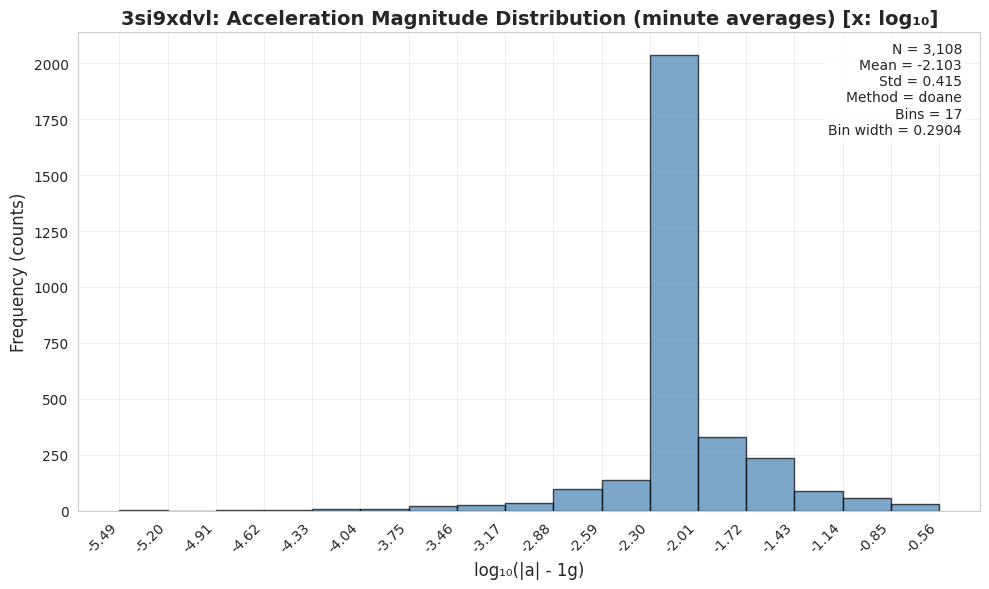


bn4j8yj9 (doane):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/bn4j8yj9_doane_logcounts_histogram.png


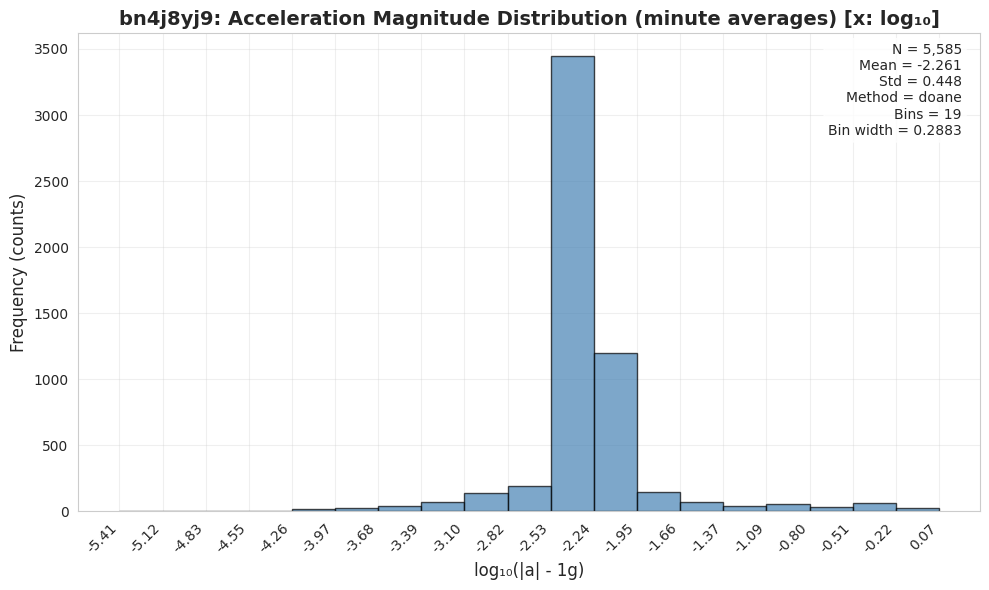


gq36edfi (doane):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/gq36edfi_doane_logcounts_histogram.png


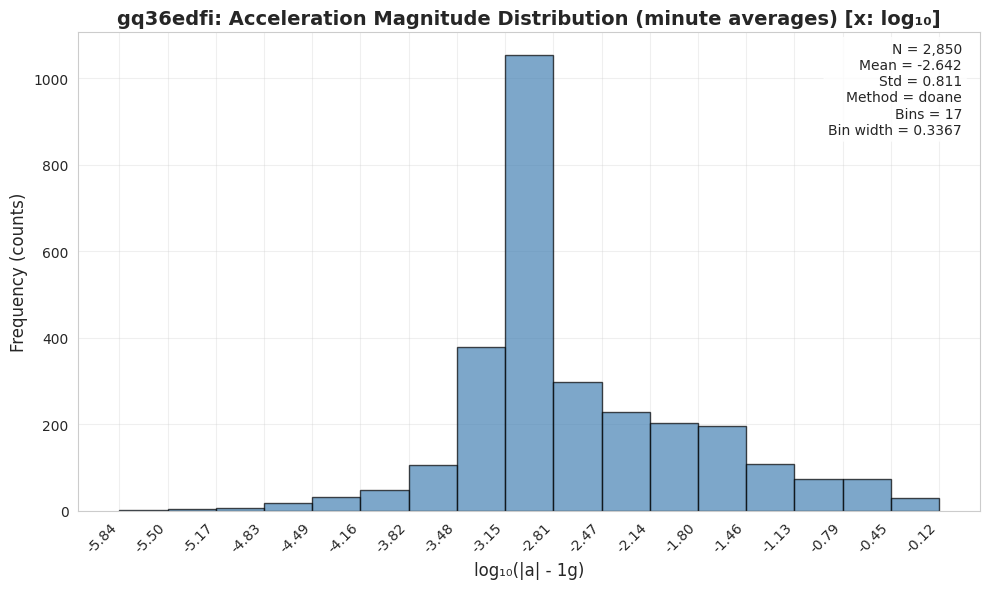


ubrmuu2r (doane):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/ubrmuu2r_doane_logcounts_histogram.png


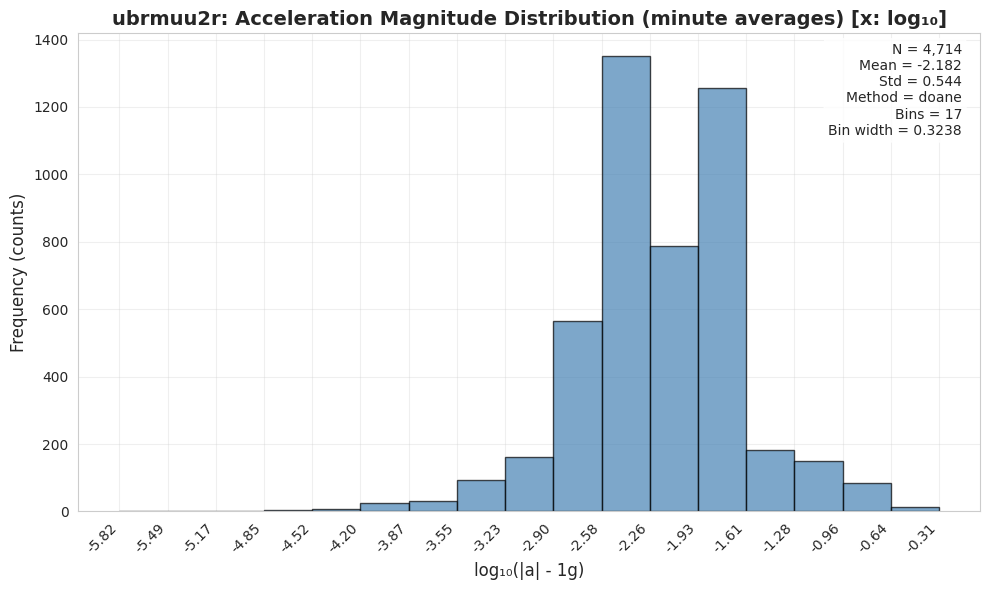


xwyd72l9 (doane):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/xwyd72l9_doane_logcounts_histogram.png


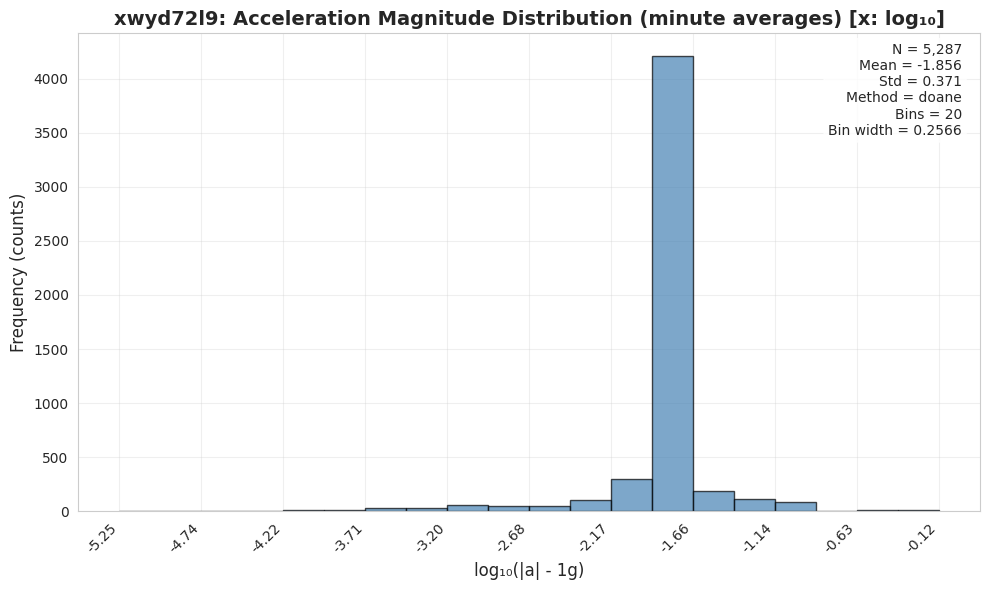


zg5uqa5l (doane):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/zg5uqa5l_doane_logcounts_histogram.png


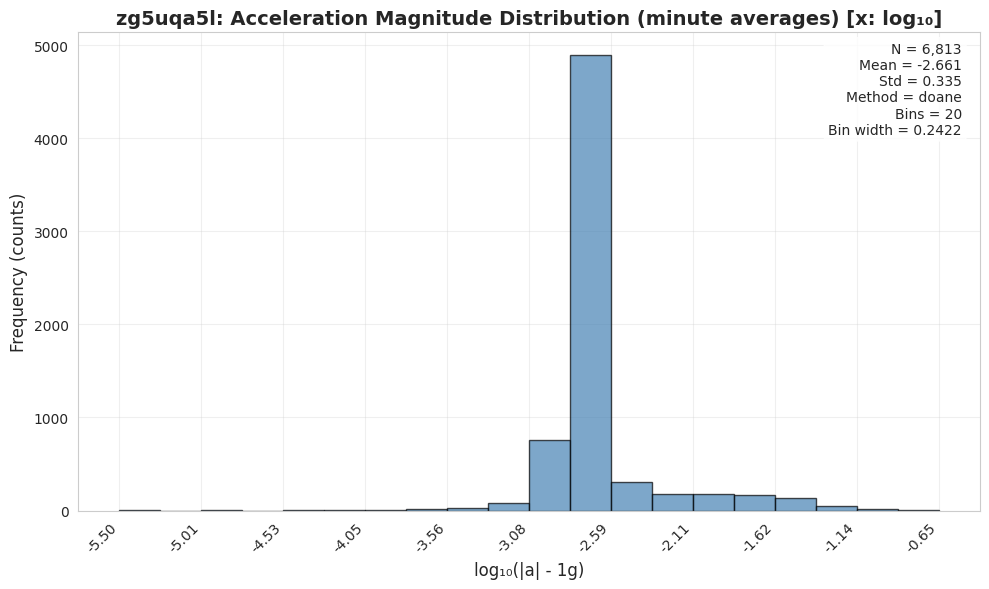


Bin method: scott

3si9xdvl (scott):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/3si9xdvl_scott_logcounts_histogram.png


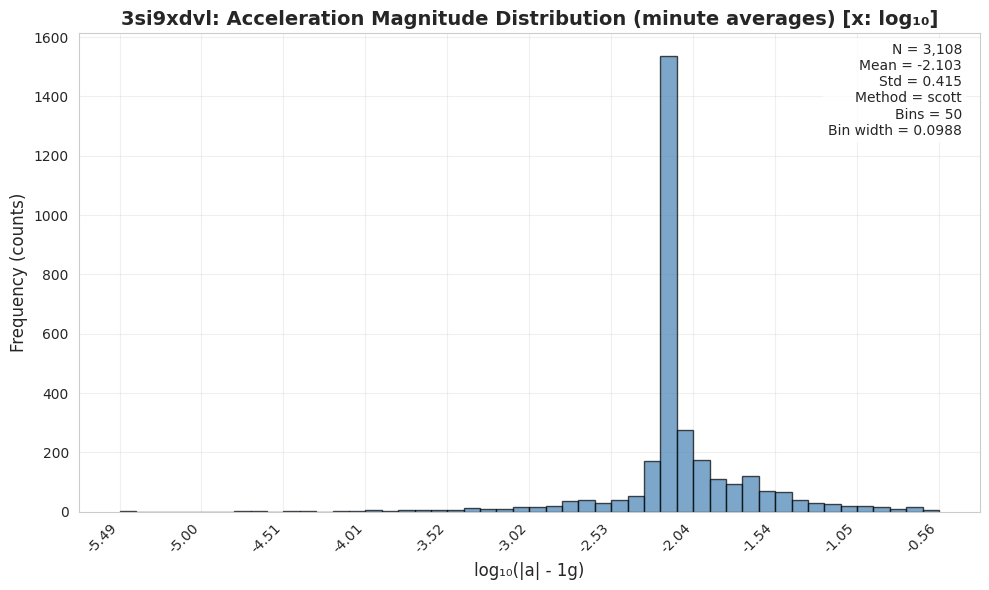


bn4j8yj9 (scott):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/bn4j8yj9_scott_logcounts_histogram.png


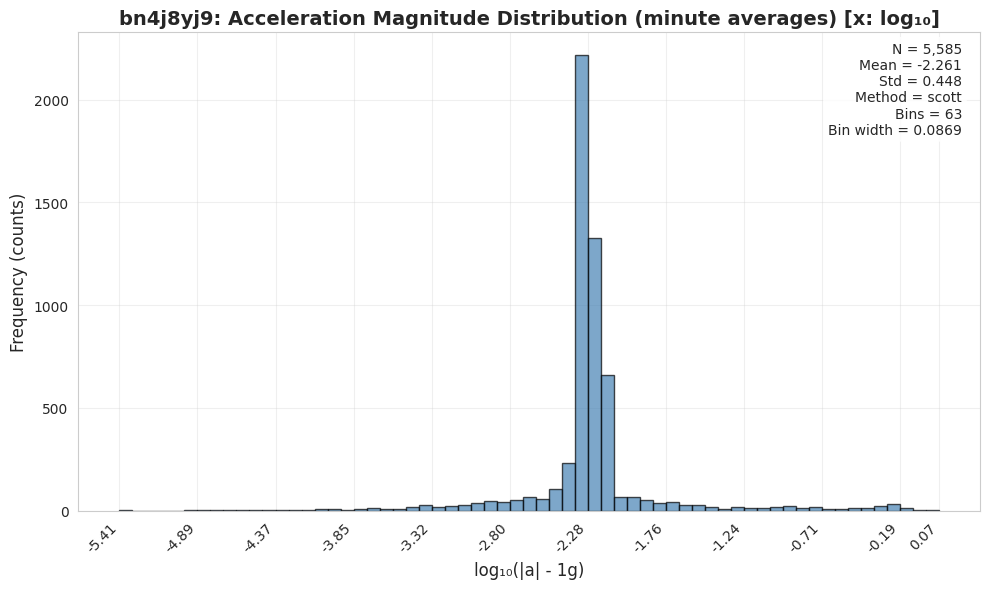


gq36edfi (scott):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/gq36edfi_scott_logcounts_histogram.png


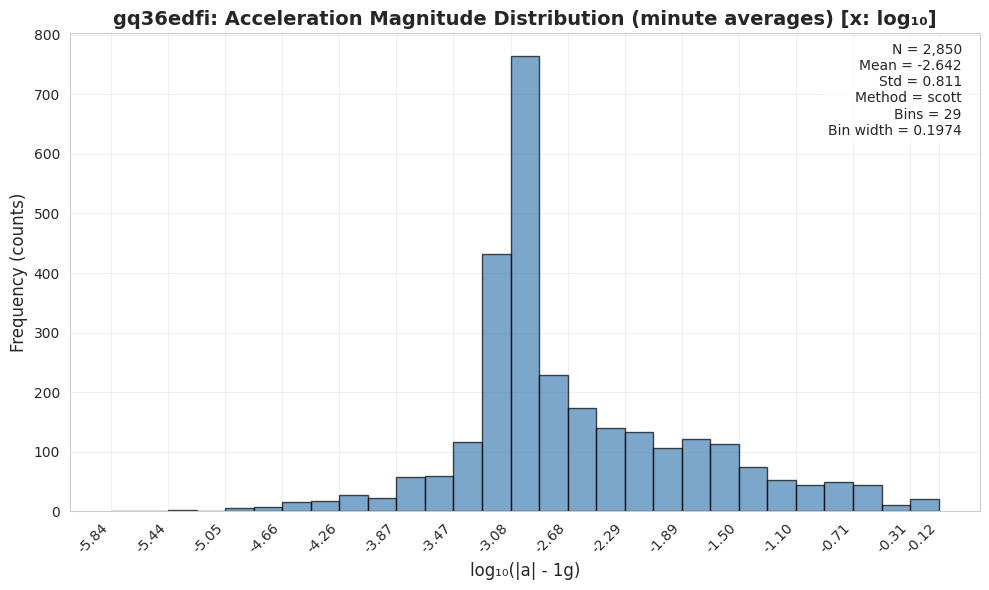


ubrmuu2r (scott):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/ubrmuu2r_scott_logcounts_histogram.png


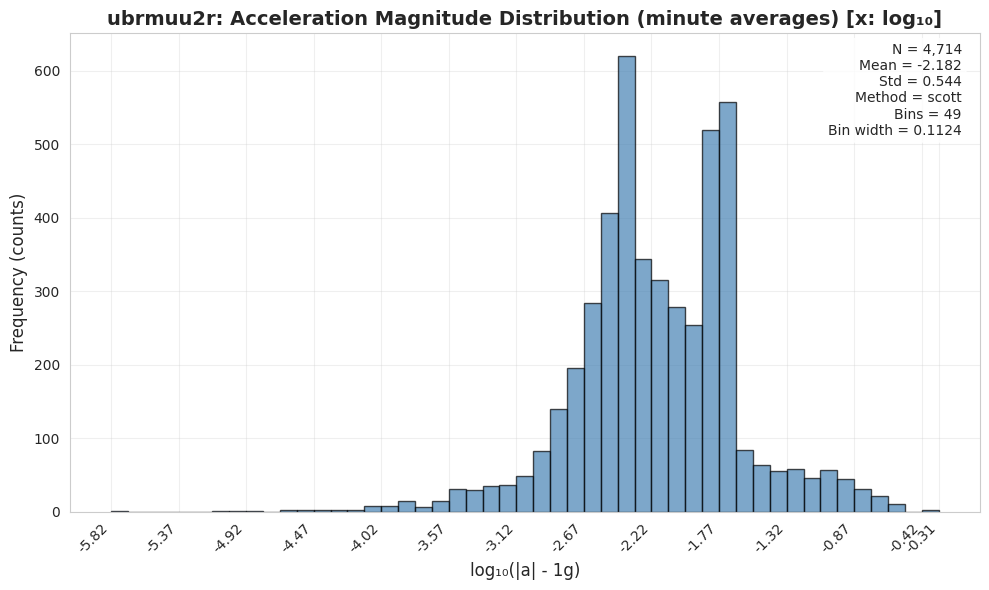


xwyd72l9 (scott):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/xwyd72l9_scott_logcounts_histogram.png


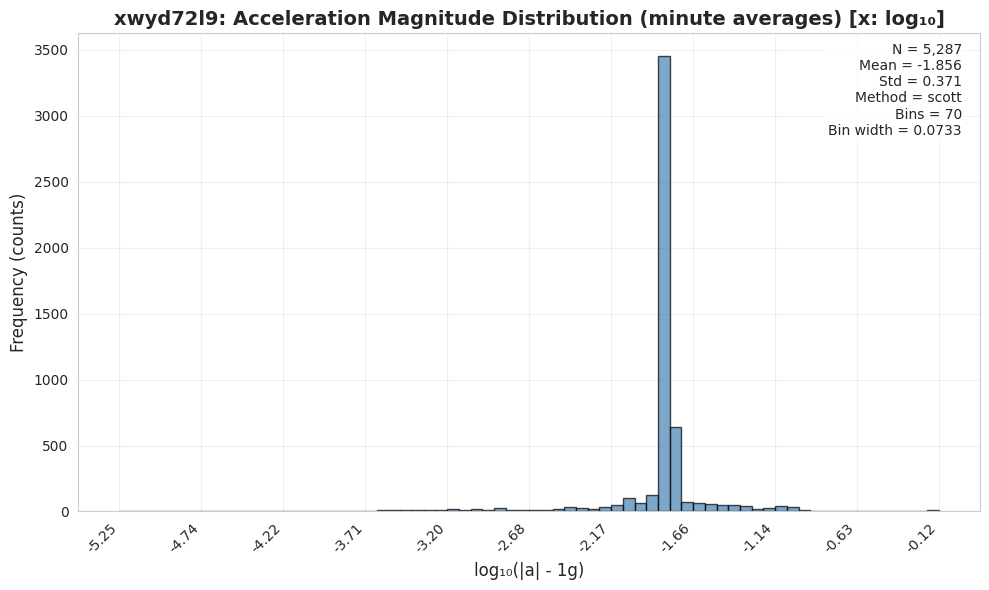


zg5uqa5l (scott):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/zg5uqa5l_scott_logcounts_histogram.png


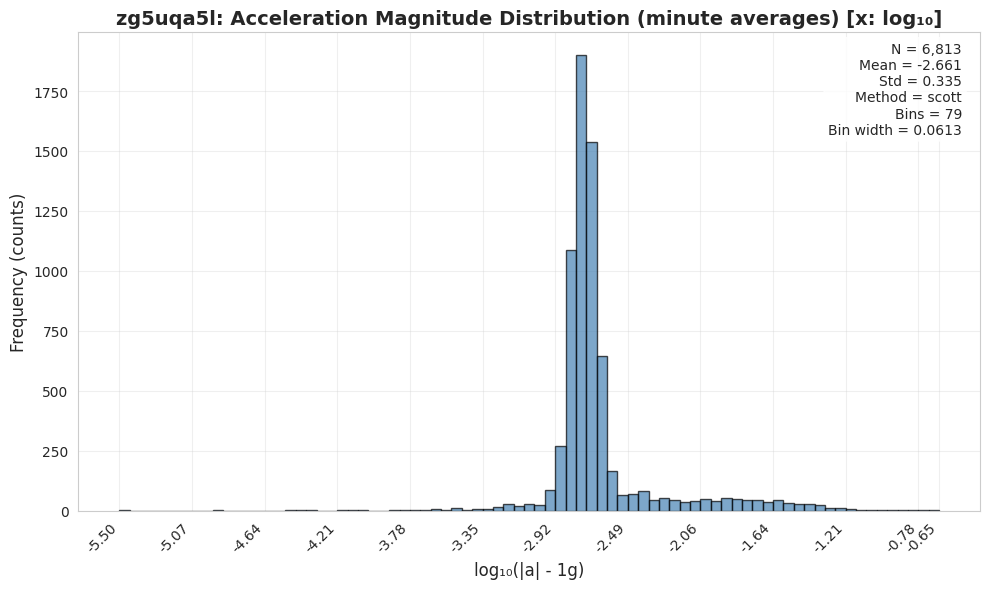


Bin method: stone

3si9xdvl (stone):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/3si9xdvl_stone_logcounts_histogram.png


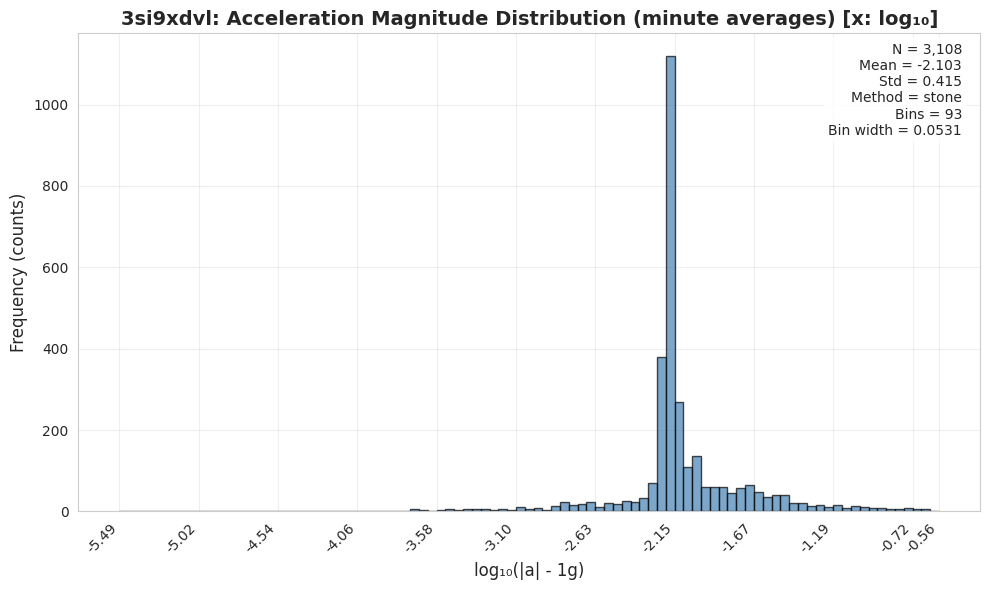


bn4j8yj9 (stone):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/bn4j8yj9_stone_logcounts_histogram.png


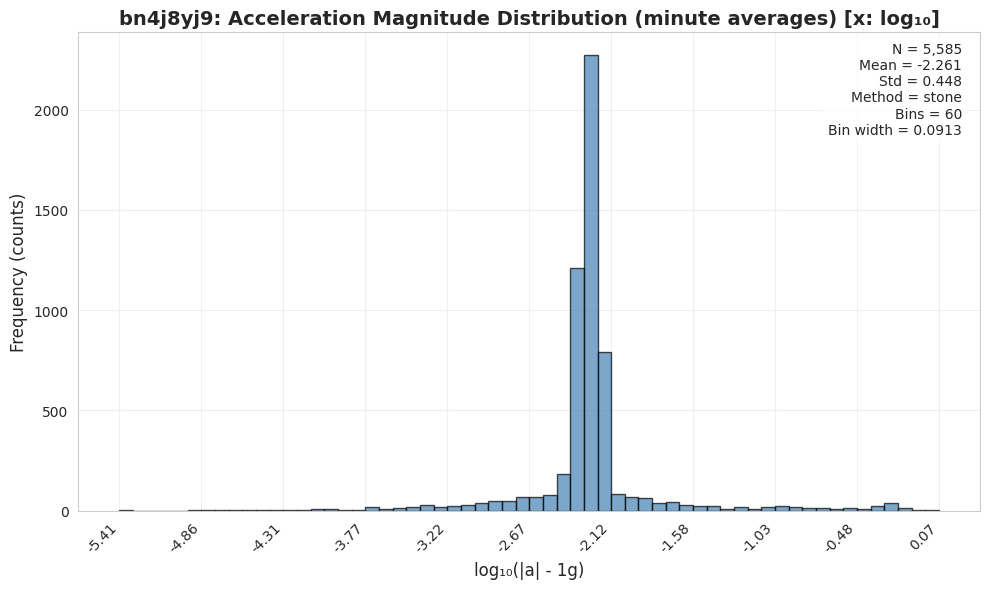


gq36edfi (stone):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/gq36edfi_stone_logcounts_histogram.png


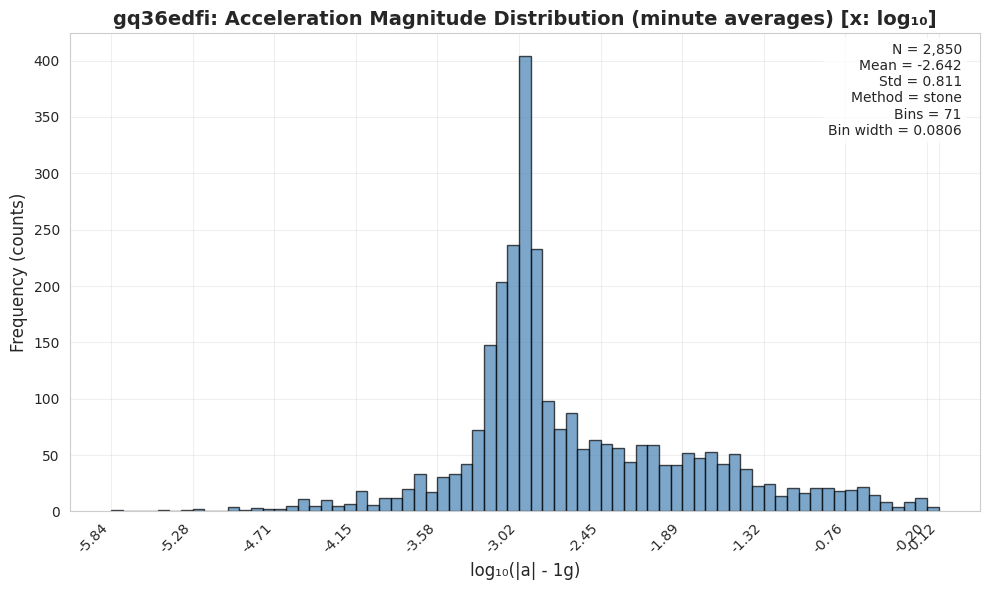


ubrmuu2r (stone):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/ubrmuu2r_stone_logcounts_histogram.png


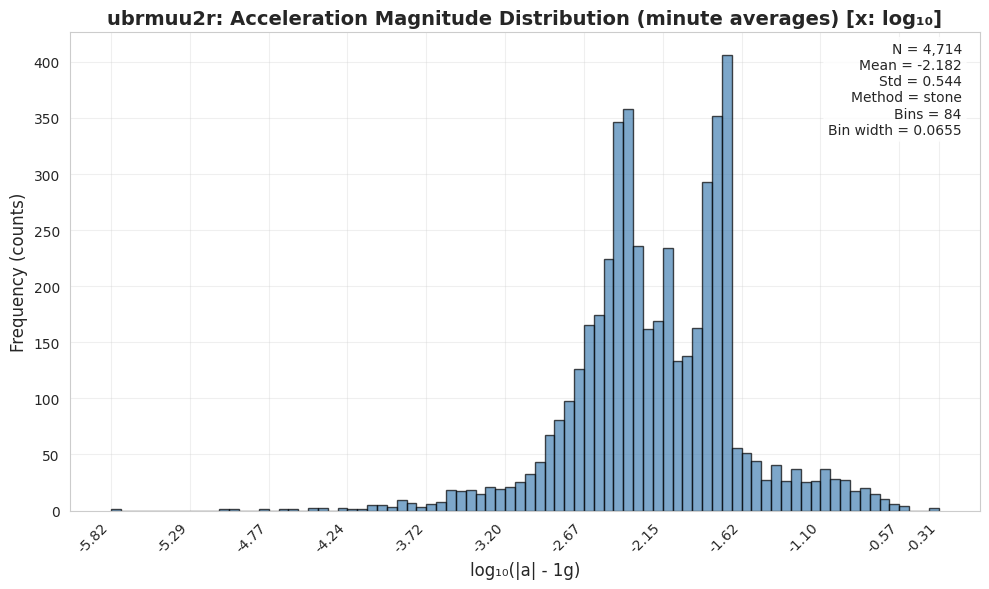


xwyd72l9 (stone):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/xwyd72l9_stone_logcounts_histogram.png


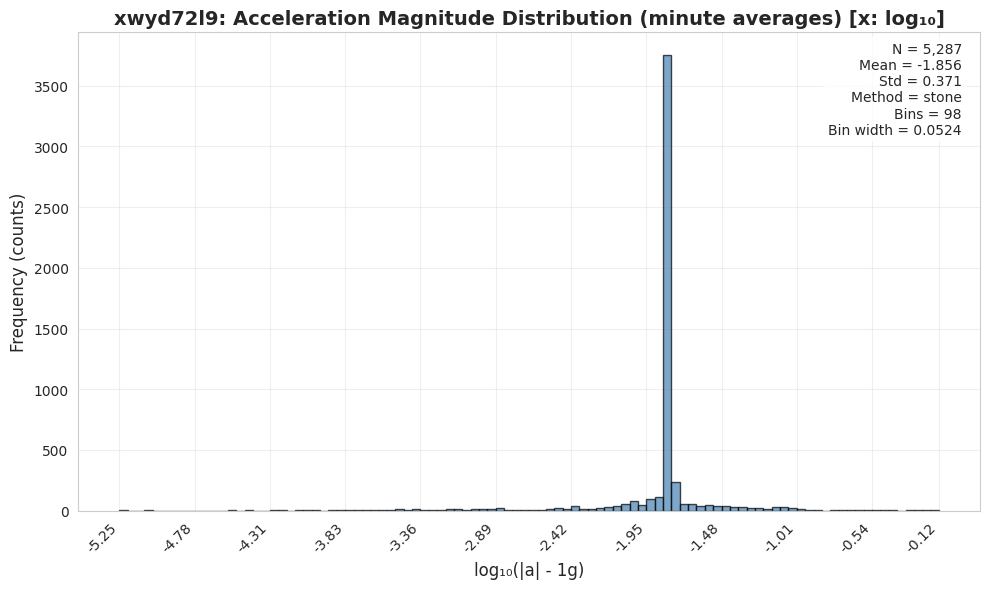


zg5uqa5l (stone):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/zg5uqa5l_stone_logcounts_histogram.png


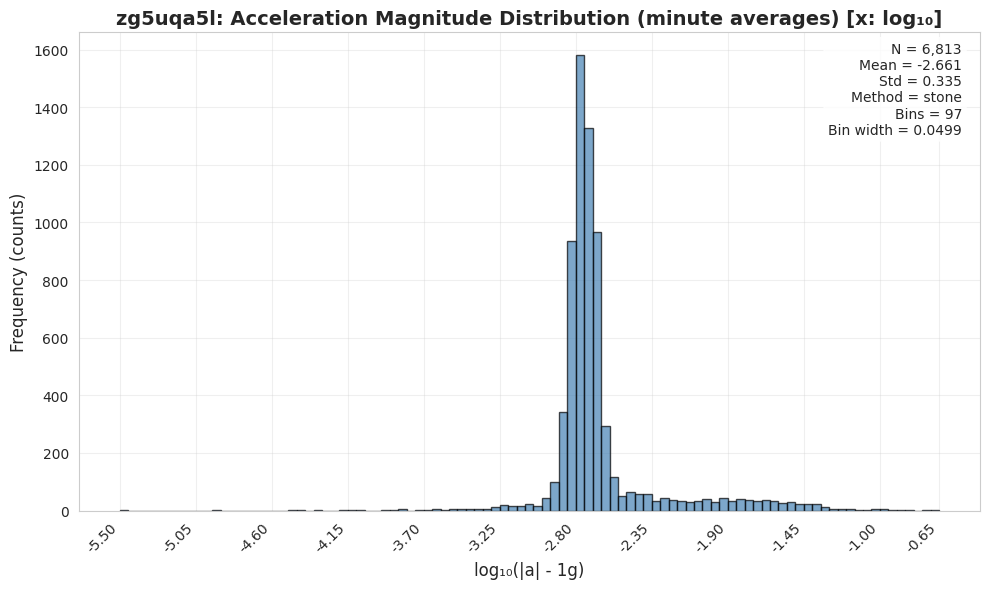


Bin method: rice

3si9xdvl (rice):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/3si9xdvl_rice_logcounts_histogram.png


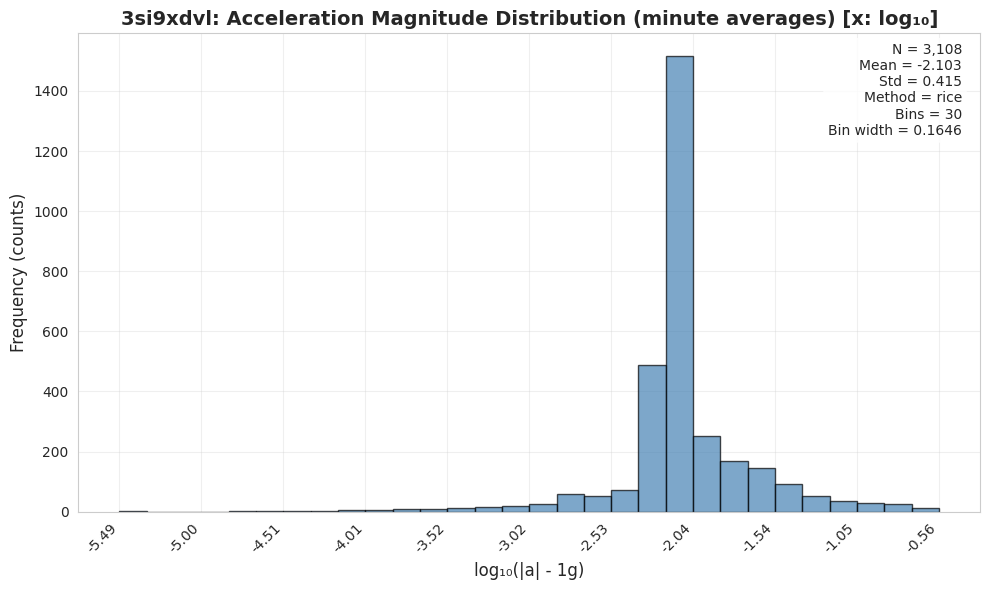


bn4j8yj9 (rice):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/bn4j8yj9_rice_logcounts_histogram.png


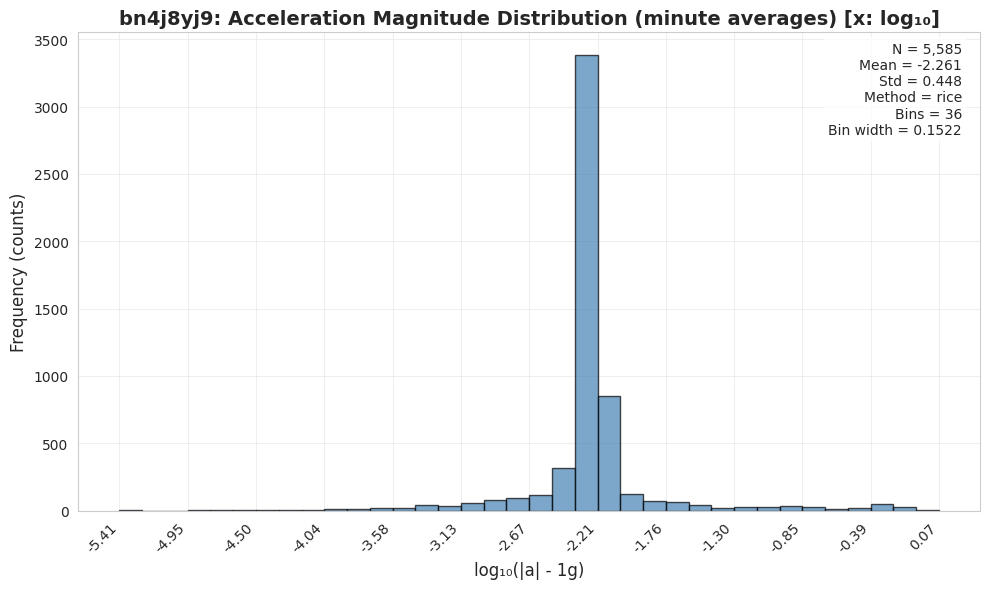


gq36edfi (rice):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/gq36edfi_rice_logcounts_histogram.png


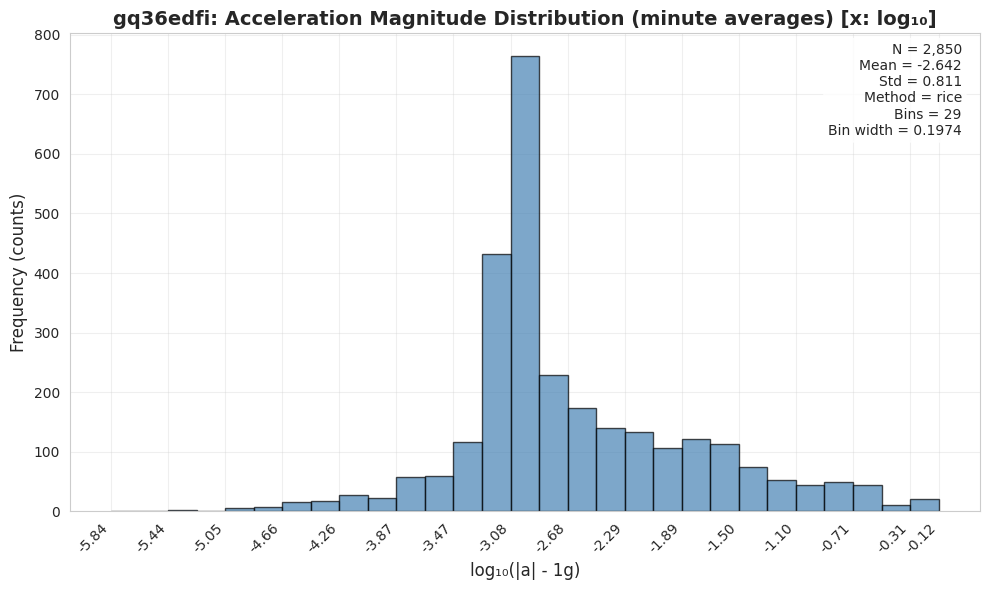


ubrmuu2r (rice):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/ubrmuu2r_rice_logcounts_histogram.png


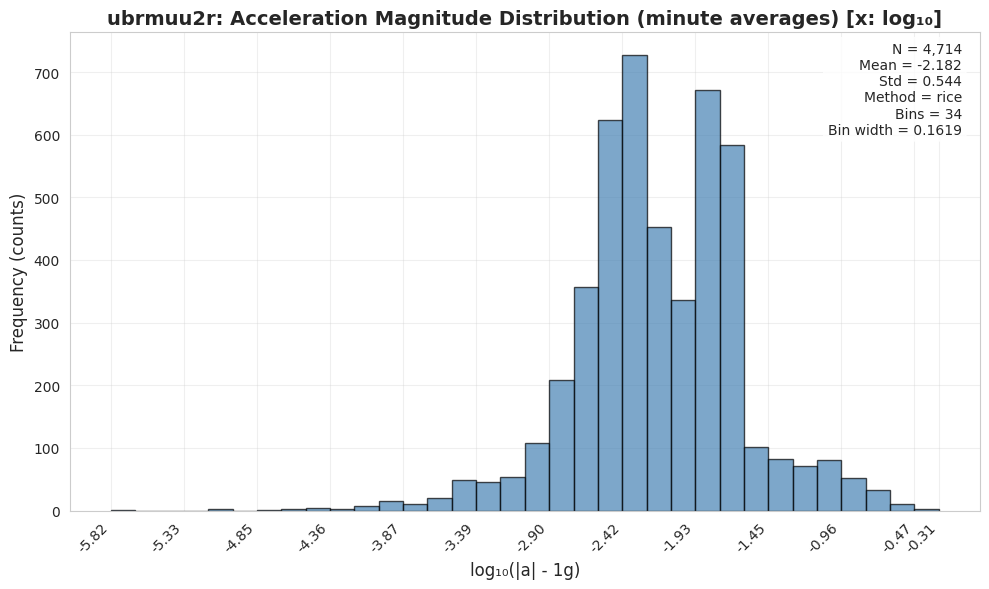


xwyd72l9 (rice):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/xwyd72l9_rice_logcounts_histogram.png


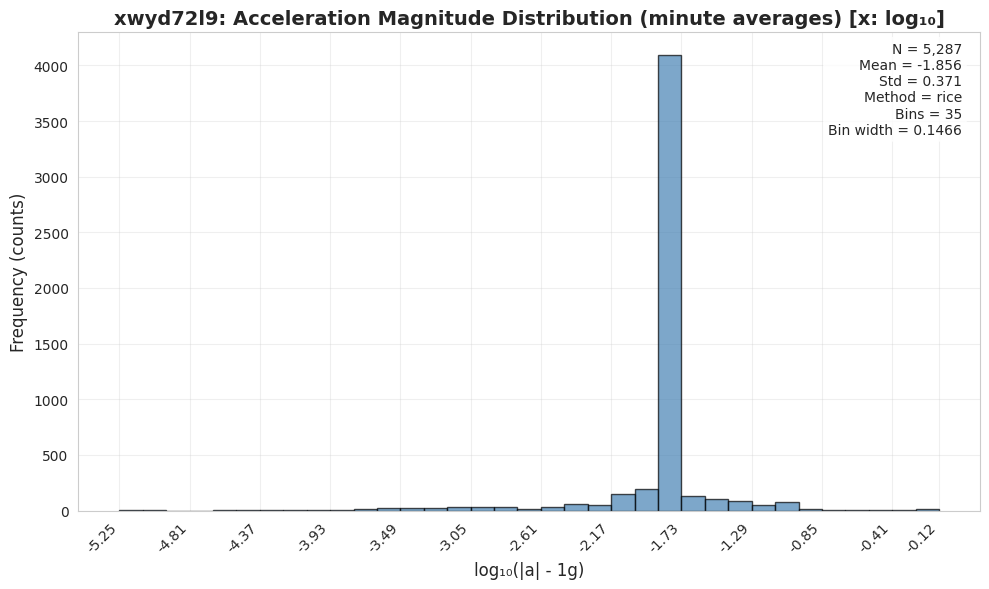


zg5uqa5l (rice):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/zg5uqa5l_rice_logcounts_histogram.png


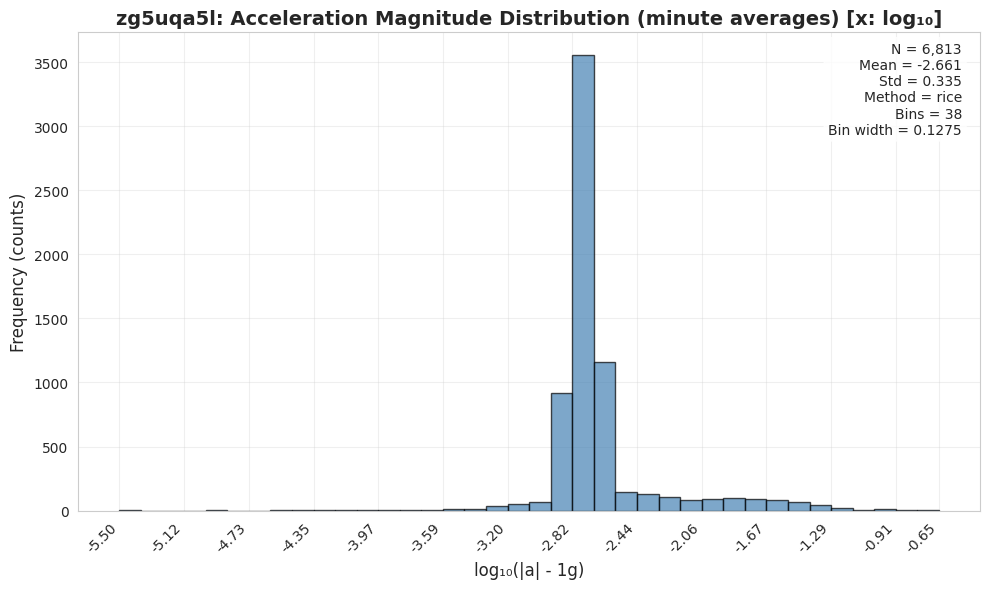


Bin method: sturges

3si9xdvl (sturges):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/3si9xdvl_sturges_logcounts_histogram.png


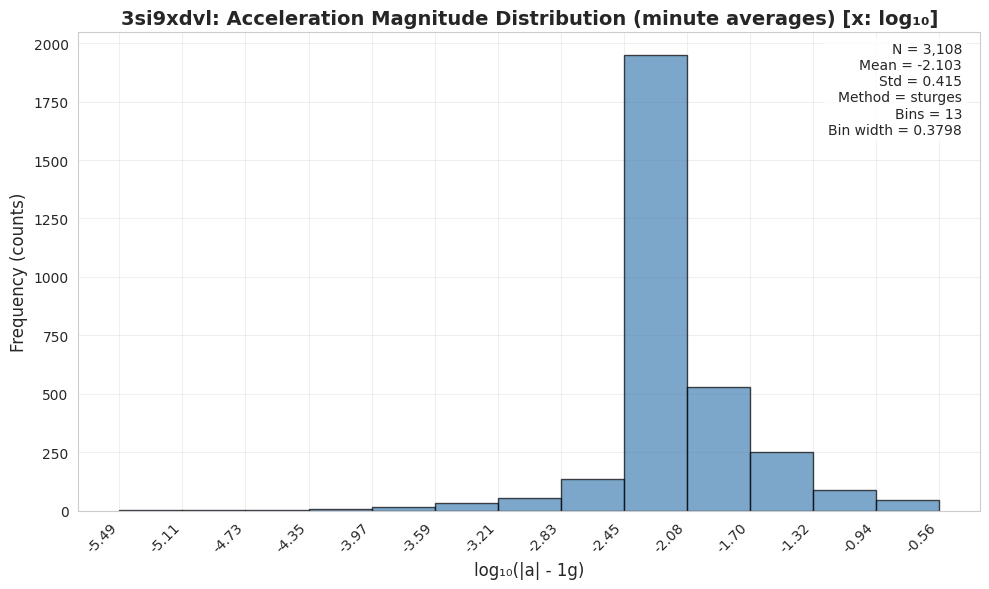


bn4j8yj9 (sturges):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/bn4j8yj9_sturges_logcounts_histogram.png


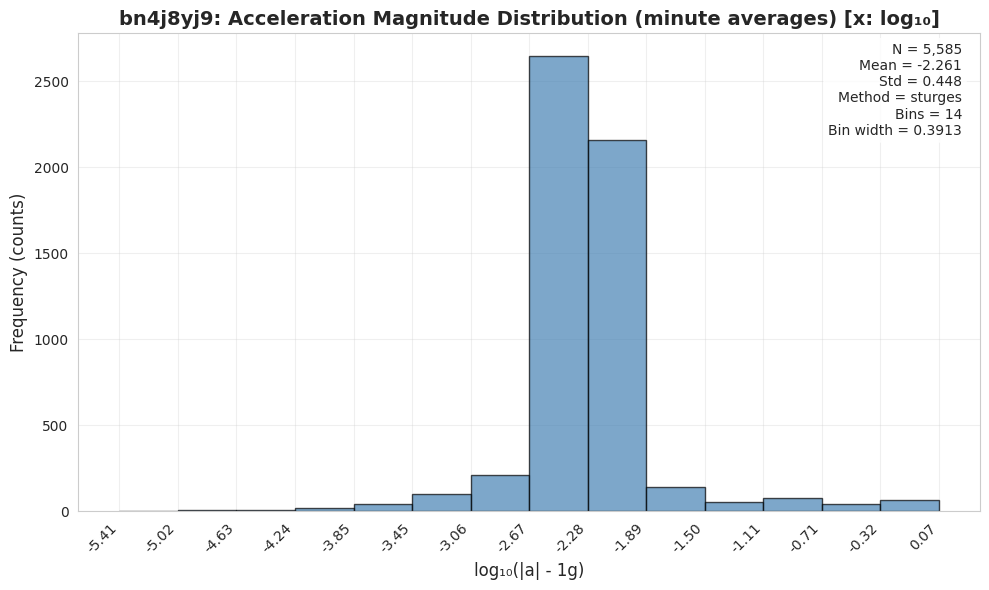


gq36edfi (sturges):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/gq36edfi_sturges_logcounts_histogram.png


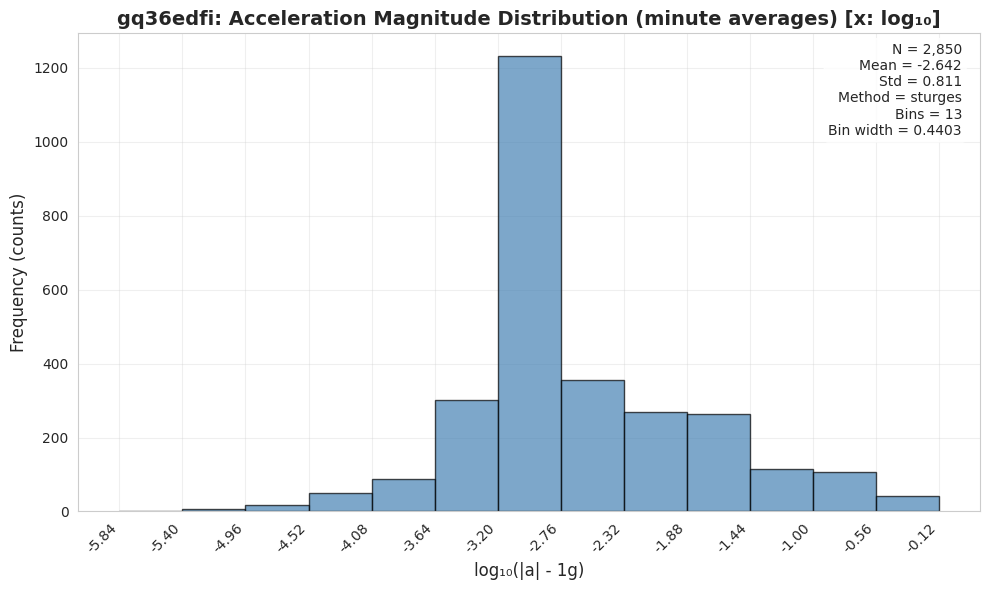


ubrmuu2r (sturges):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/ubrmuu2r_sturges_logcounts_histogram.png


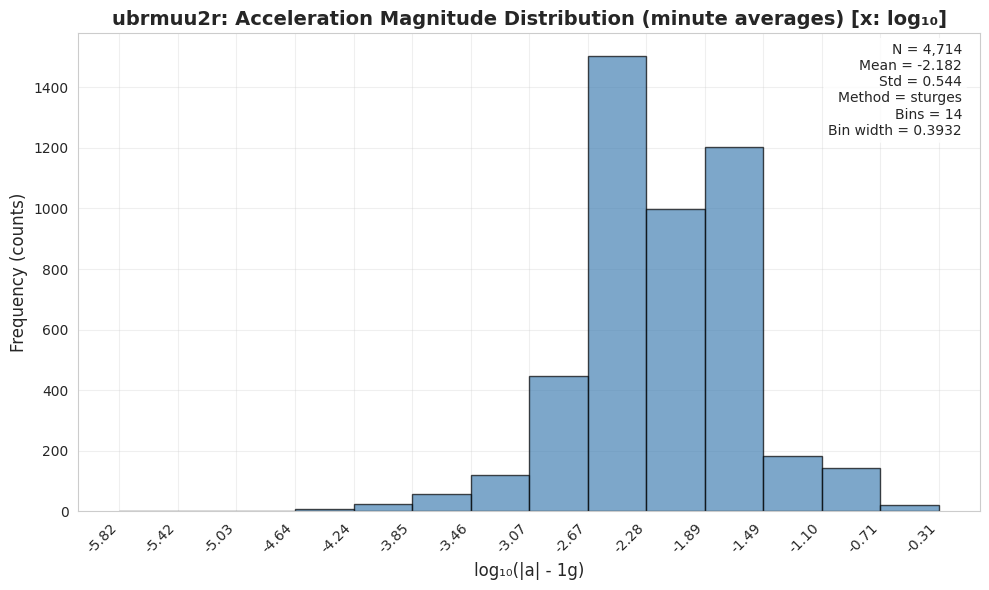


xwyd72l9 (sturges):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/xwyd72l9_sturges_logcounts_histogram.png


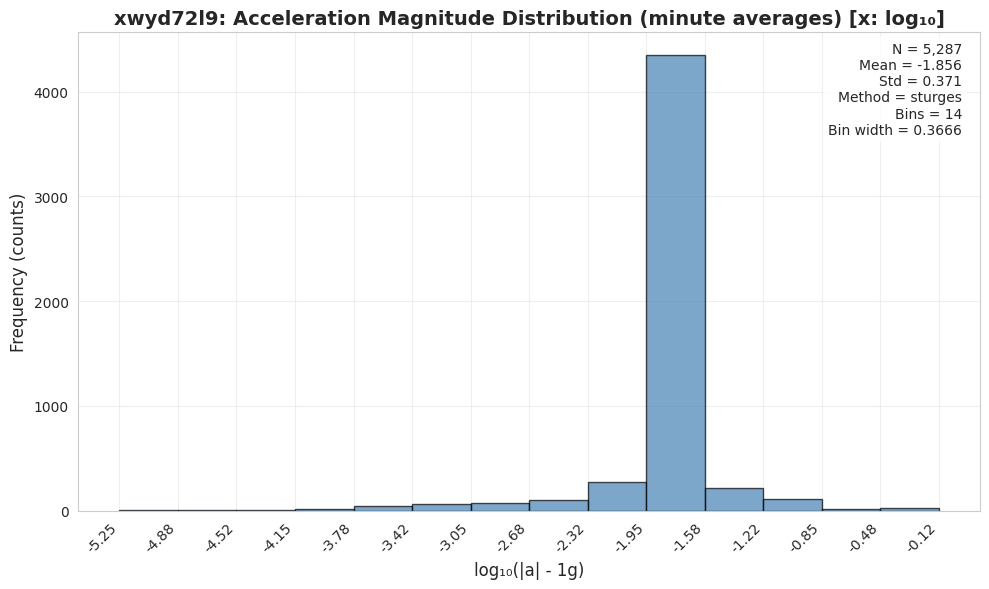


zg5uqa5l (sturges):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/zg5uqa5l_sturges_logcounts_histogram.png


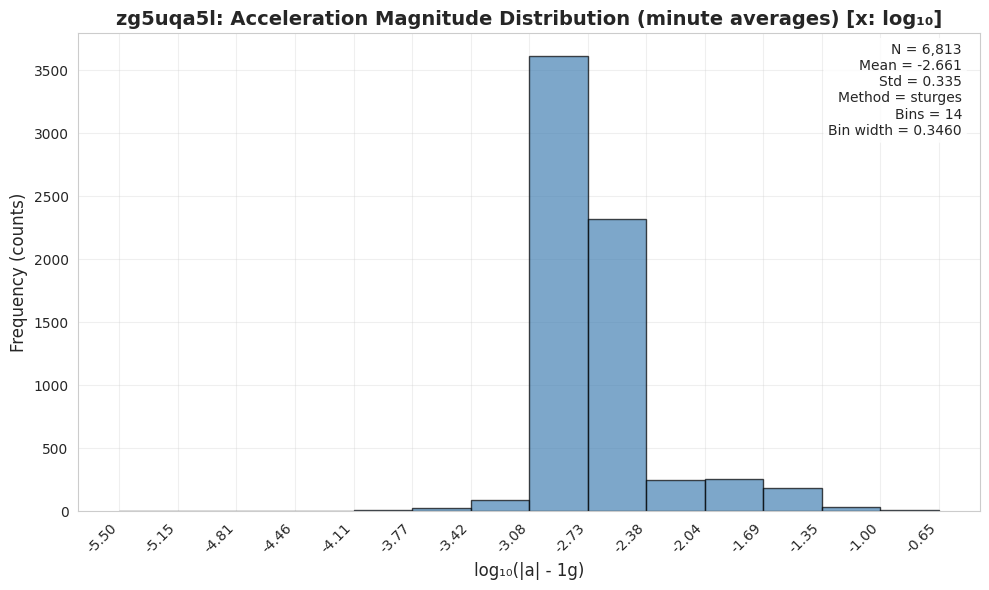


Bin method: sqrt

3si9xdvl (sqrt):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/3si9xdvl_sqrt_logcounts_histogram.png


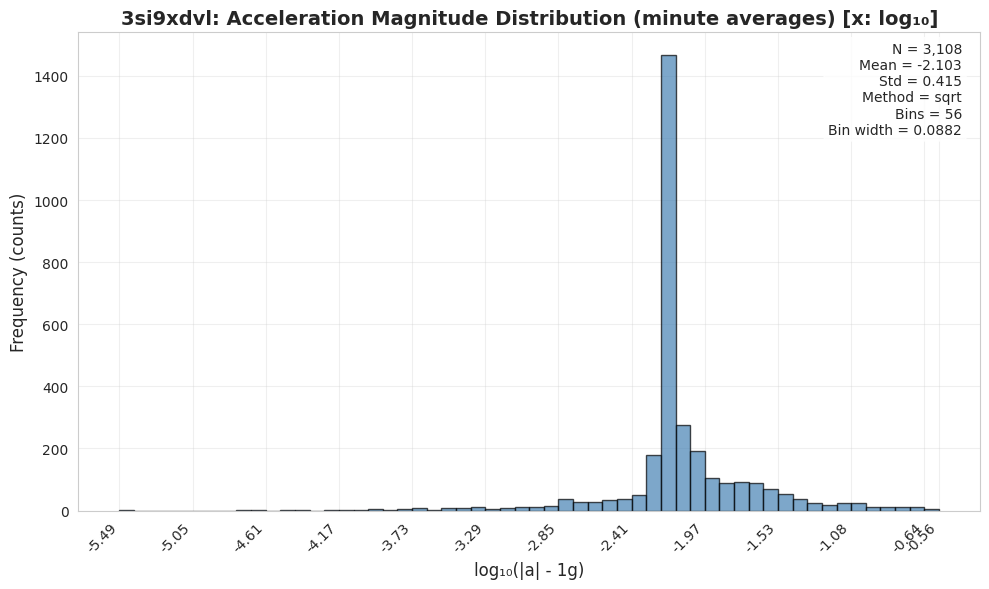


bn4j8yj9 (sqrt):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/bn4j8yj9_sqrt_logcounts_histogram.png


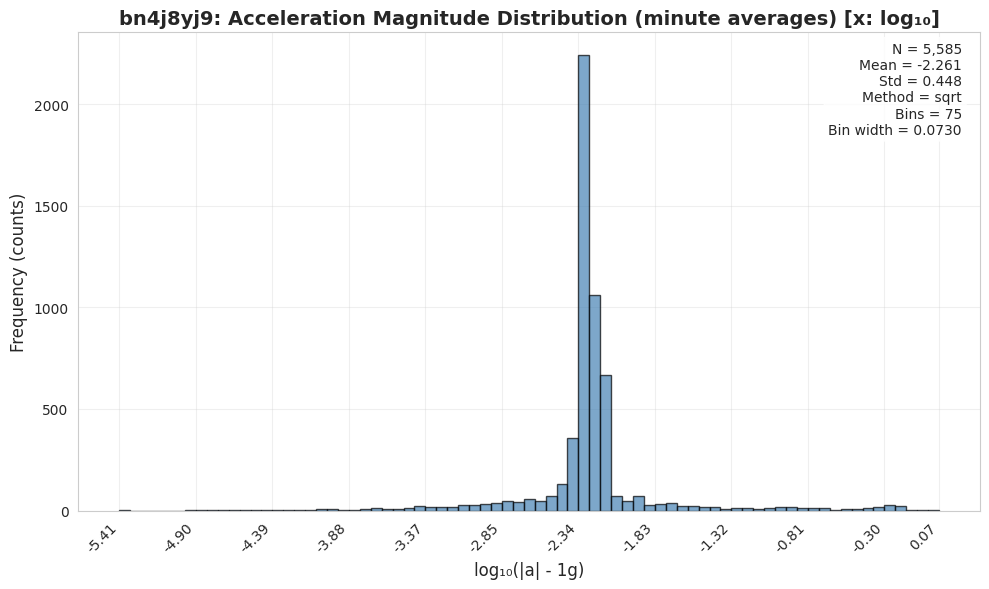


gq36edfi (sqrt):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/gq36edfi_sqrt_logcounts_histogram.png


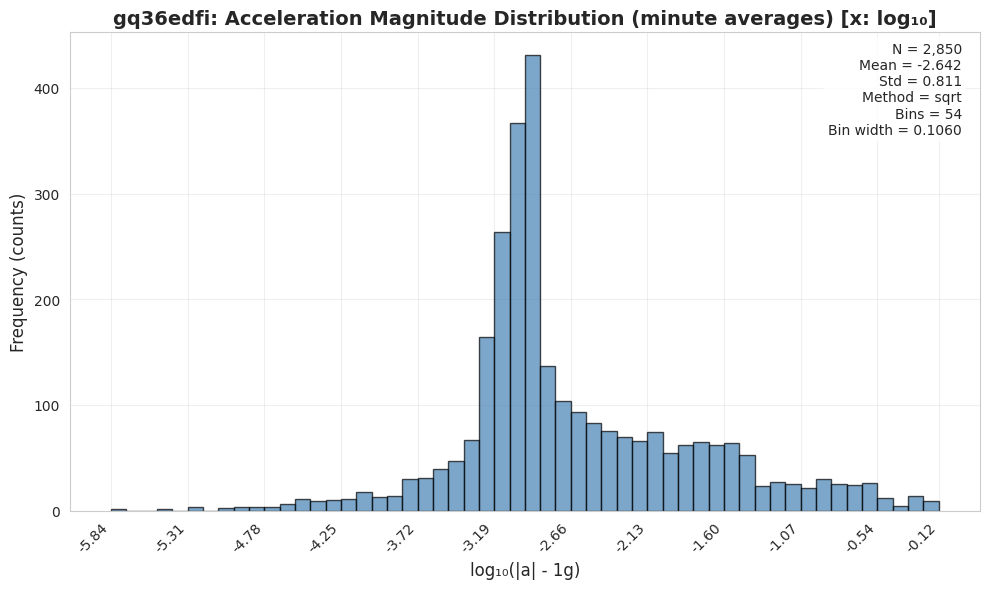


ubrmuu2r (sqrt):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/ubrmuu2r_sqrt_logcounts_histogram.png


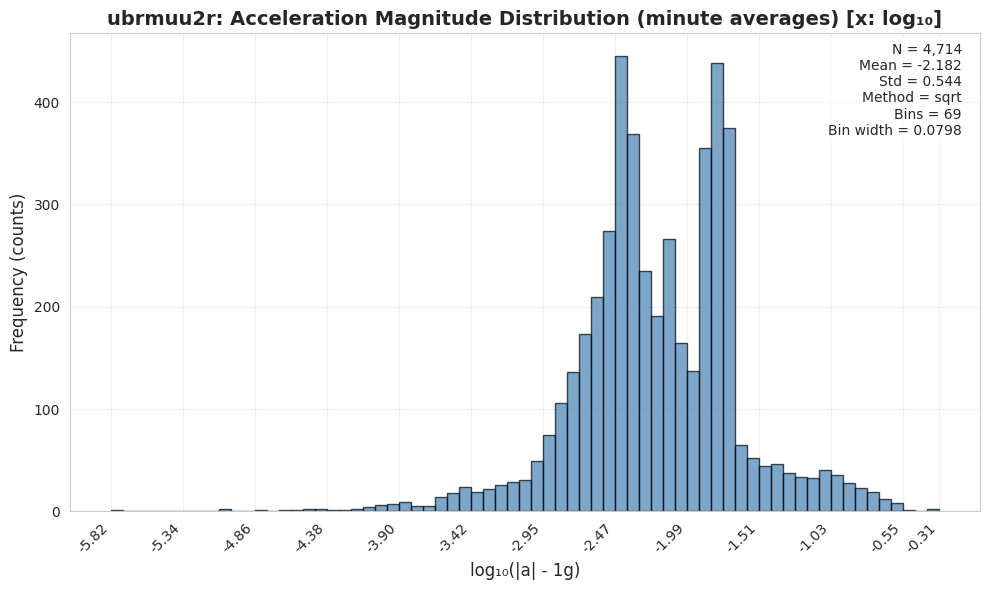


xwyd72l9 (sqrt):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/xwyd72l9_sqrt_logcounts_histogram.png


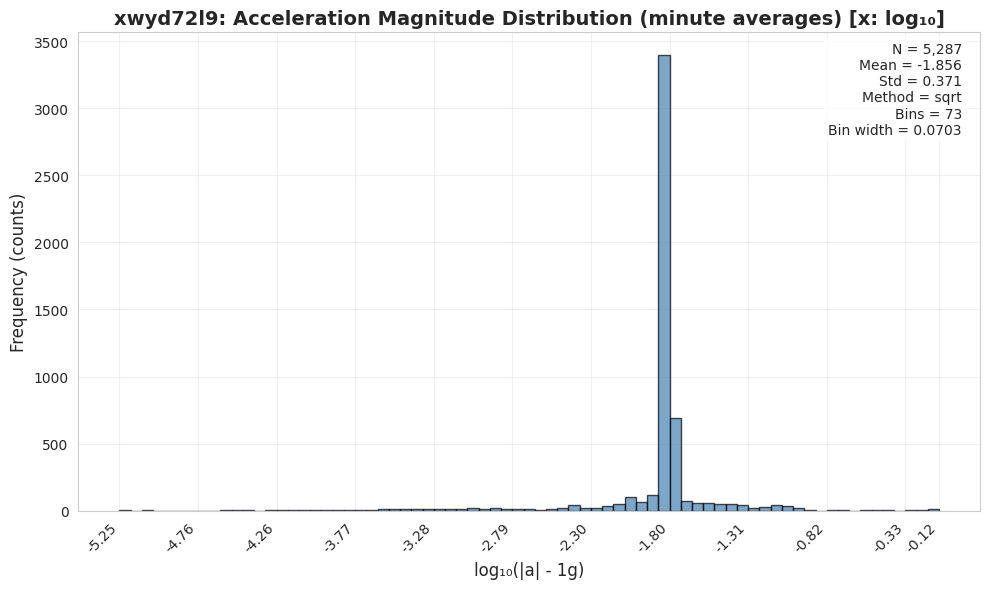


zg5uqa5l (sqrt):
  Saved histogram to /n/home01/egraff/sample_imputation/plots/zg5uqa5l_sqrt_logcounts_histogram.png


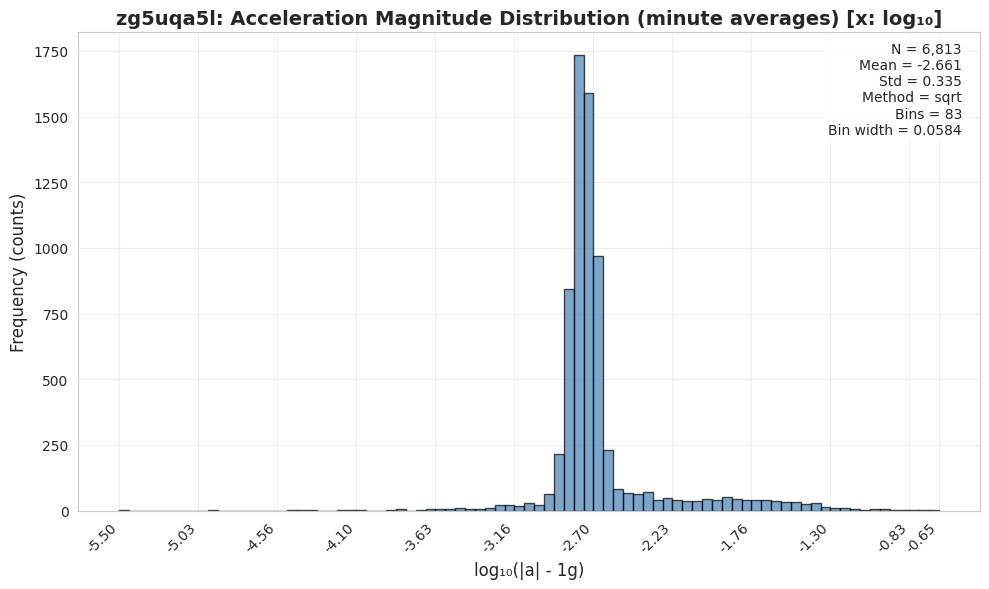


Generated log-count histograms for 6 subjects × 8 bin methods
Total: 48 histograms


In [ ]:
# Generate log-count histograms for all subjects using ALL bin methods
print("Generating histograms of log magnitude for all bin methods...")
print("="*70)

for bin_method in BIN_METHODS:
    print(f"\n{'='*70}")
    print(f"Bin method: {bin_method}")
    print(f"{'='*70}")
    
    for subject_id in SUBJECT_IDS:
        print(f"\n{subject_id} ({bin_method}):")
        save_path = PLOTS_DIR / f"{subject_id}_{bin_method}_logcounts_histogram.png"
        fig = plot_magnitude_histogram(
            processed_data[subject_id],
            subject_id,
            use_log=True,
            log_counts=False,
            resolution='minute',
            resolution_count=1,
            bin_method=bin_method,
            save_path=save_path
        )
        plt.show()
        plt.close(fig)

print(f"\n{'='*70}")
print(f"Generated log-count histograms for {len(SUBJECT_IDS)} subjects × {len(BIN_METHODS)} bin methods")
print(f"Total: {len(SUBJECT_IDS) * len(BIN_METHODS)} histograms")
print(f"{'='*70}")


In [ ]:
print("="*70)

print(f"\nProcessed Data:")
print(f"  Subjects: {len(SUBJECT_IDS)}")
print(f"  iOS devices (g units): {sum(1 for d in device_types.values() if d == 'ios')}")
print(f"  Android devices (m/s² → g): {sum(1 for d in device_types.values() if d == 'android')}")

print(f"\nStandardized data saved to:")
print(f"  {DATA_PROCESSED}")

print(f"\nGenerated plots saved to:")
print(f"  {PLOTS_DIR}")
print(f"  - Magnitude histograms (linear x, linear y): {len(SUBJECT_IDS)} files")
print(f"  - Log counts histograms (linear x, log y): {len(SUBJECT_IDS)} files")




Processed Data:
  Subjects: 6
  iOS devices (g units): 4
  Android devices (m/s² → g): 2

Standardized data saved to:
  /n/home01/egraff/sample_imputation/data/processed/g_units

Generated plots saved to:
  /n/home01/egraff/sample_imputation/plots
  - Magnitude histograms (linear x, linear y): 6 files
  - Log counts histograms (linear x, log y): 6 files


## 4. Knuth's Optimal Binning Method

Use astropy's `knuth_bin_width` function for Bayesian-optimal histogram binning. Knuth's rule maximizes a posterior probability for the number of bins, making it particularly robust for determining bin widths without assuming a specific distribution shape.

Reference: Knuth, K.H. "Optimal Data-Based Binning for Histograms". arXiv:0605197, 2006


In [ ]:
from astropy.stats import knuth_bin_width


def plot_knuth_histogram(
    data: pd.DataFrame,
    subject_id: str,
    log_counts: bool = False,
    resolution: Literal['minute', 'hour', 'day'] = 'minute',
    resolution_count: int = 1,
    ax: plt.Axes | None = None,
    save_path: Path | None = None
) -> plt.Figure:
    """
    Plot histogram of acceleration magnitudes using Knuth's optimal binning.
    
    Parameters
    ----------
    data : pd.DataFrame
        DataFrame with columns: timestamp, x, y, z (acceleration in g units)
    subject_id : str
        Subject identifier (for plot title)
    log_counts : bool, default False
        If True, use log scale for y-axis (counts)
    resolution : {'minute', 'hour', 'day'}, default 'minute'
        Time resolution for averaging
    resolution_count : int, default 1
        Number of resolution units (e.g., 3 for "3 hours")
    ax : plt.Axes or None, default None
        Axes to plot on. If None, creates new figure.
    save_path : Path or None, default None
        If provided, saves figure to this path.
        
    Returns
    -------
    plt.Figure
        The matplotlib figure object
    """
    df = data.copy()
    
    # Compute per-sample magnitude and subtract 1g to account for gravity
    df['magnitude'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2) - 1.0
    
    # Build pandas frequency string
    freq_map = {'minute': 'min', 'hour': 'h', 'day': 'D'}
    freq_str = f'{resolution_count}{freq_map[resolution]}'
    
    # Set timestamp as index for resampling
    df = df.set_index('timestamp')
    
    # Resample to specified resolution, taking mean of magnitudes
    resampled = df['magnitude'].resample(freq_str).mean().dropna()
    
    if len(resampled) == 0:
        raise ValueError(f"No data after resampling at {resolution_count} {resolution}(s)")
    
    values = resampled.values
    
    # Use Knuth's rule for optimal bin width
    bin_width, bin_edges = knuth_bin_width(values, return_bins=True, quiet=True)
    n_bins = len(bin_edges) - 1
    
    # Create figure if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.get_figure()
    
    # Plot histogram
    hist_kwargs = {'edgecolor': 'black', 'alpha': 0.7, 'color': 'darkorange'}
    counts, _, patches = ax.hist(values, bins=bin_edges, **hist_kwargs)
    
    # Set x-axis ticks to show bin edges (show subset if too many)
    if n_bins <= 15:
        ax.set_xticks(bin_edges)
        ax.set_xticklabels([f'{edge:.2f}' for edge in bin_edges], rotation=45, ha='right')
    else:
        step = max(1, n_bins // 10)
        tick_indices = list(range(0, len(bin_edges), step))
        if tick_indices[-1] != len(bin_edges) - 1:
            tick_indices.append(len(bin_edges) - 1)
        ax.set_xticks([bin_edges[i] for i in tick_indices])
        ax.set_xticklabels([f'{bin_edges[i]:.2f}' for i in tick_indices], rotation=45, ha='right')
    
    # Apply log scale to y-axis if requested
    if log_counts:
        ax.set_yscale('log')
        y_label = 'Frequency (log counts)'
    else:
        y_label = 'Frequency (counts)'
    
    # Labels and title
    resolution_label = f'{resolution_count} {resolution}' if resolution_count > 1 else resolution
    title = f'{subject_id}: Acceleration Magnitude Distribution ({resolution_label} averages) [Knuth binning]'
    if log_counts:
        title += ' [y: log]'
    
    ax.set_xlabel('|a| - 1g (g)', fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add stats annotation with Knuth bin info
    stats_text = (
        f'N = {len(values):,}\n'
        f'Mean = {values.mean():.3f}\n'
        f'Std = {values.std():.3f}\n'
        f'Method = Knuth\n'
        f'Bins = {n_bins}\n'
        f'Bin width = {bin_width:.4f}'
    )
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved histogram to {save_path}")
    
    return fig


print("Knuth histogram function defined.")


Knuth histogram function defined.


Generating magnitude histograms using Knuth's optimal binning...

3si9xdvl:
  Saved histogram to /n/home01/egraff/sample_imputation/plots/3si9xdvl_knuth_magnitude_histogram.png


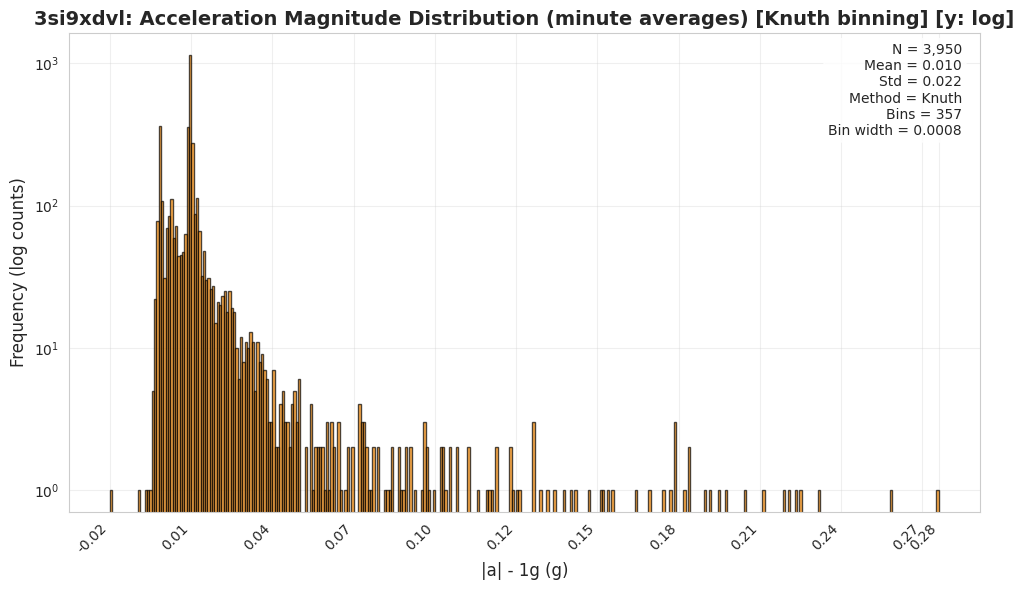


bn4j8yj9:
  Saved histogram to /n/home01/egraff/sample_imputation/plots/bn4j8yj9_knuth_magnitude_histogram.png


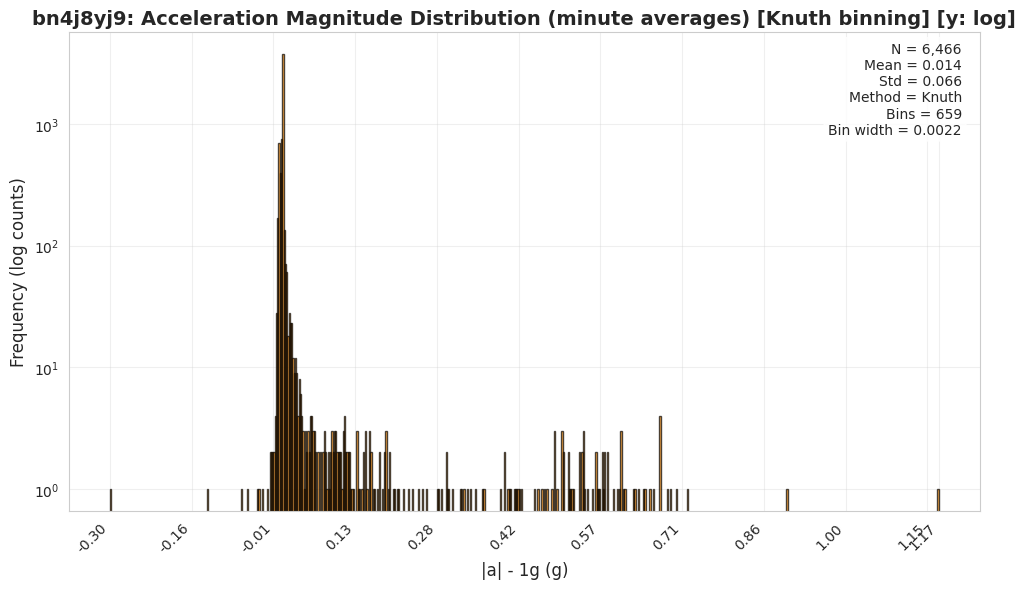


gq36edfi:
  Saved histogram to /n/home01/egraff/sample_imputation/plots/gq36edfi_knuth_magnitude_histogram.png


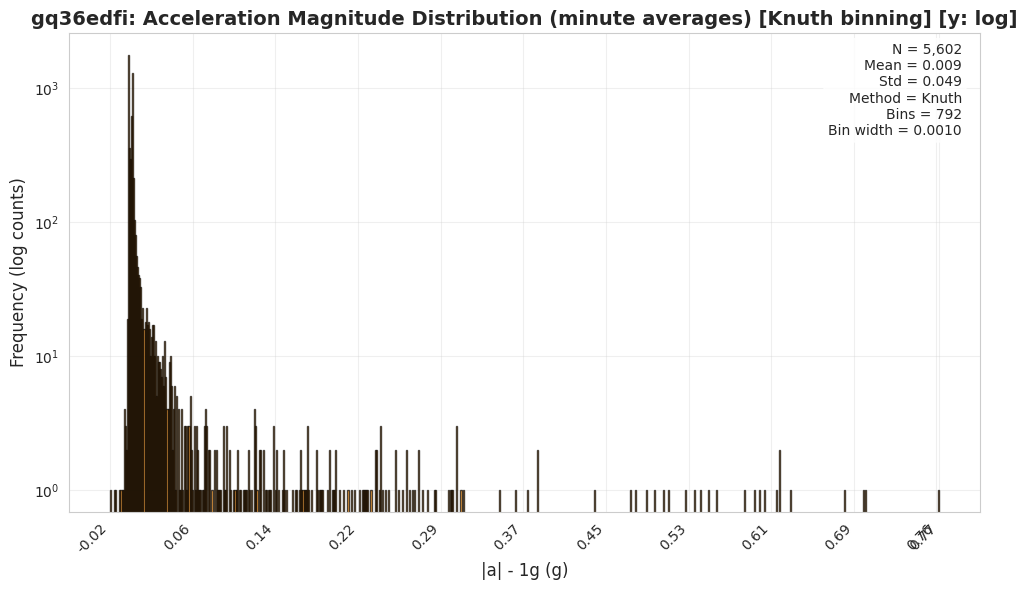


ubrmuu2r:
  Saved histogram to /n/home01/egraff/sample_imputation/plots/ubrmuu2r_knuth_magnitude_histogram.png


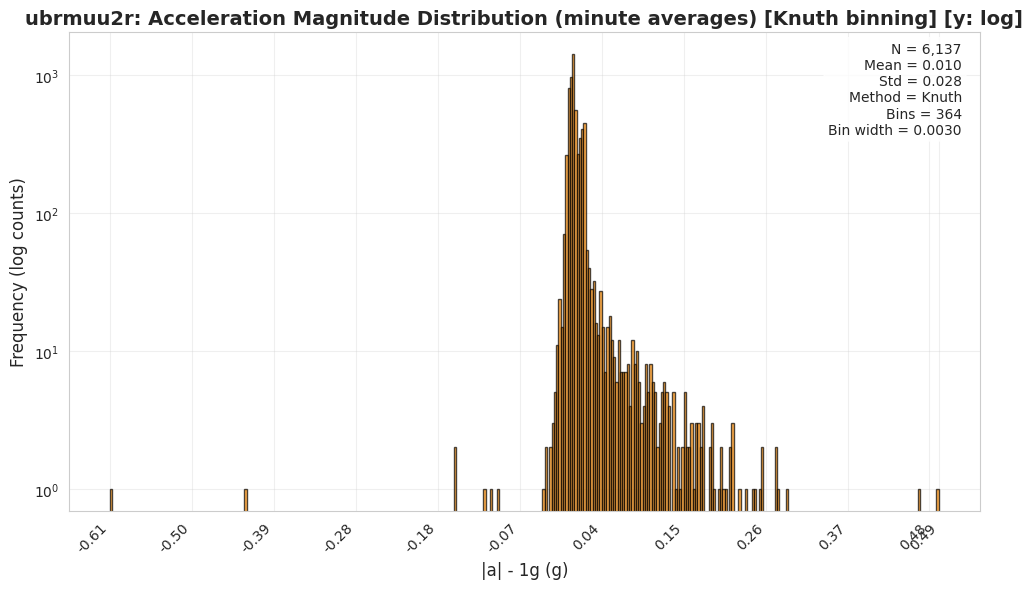


xwyd72l9:
  Saved histogram to /n/home01/egraff/sample_imputation/plots/xwyd72l9_knuth_magnitude_histogram.png


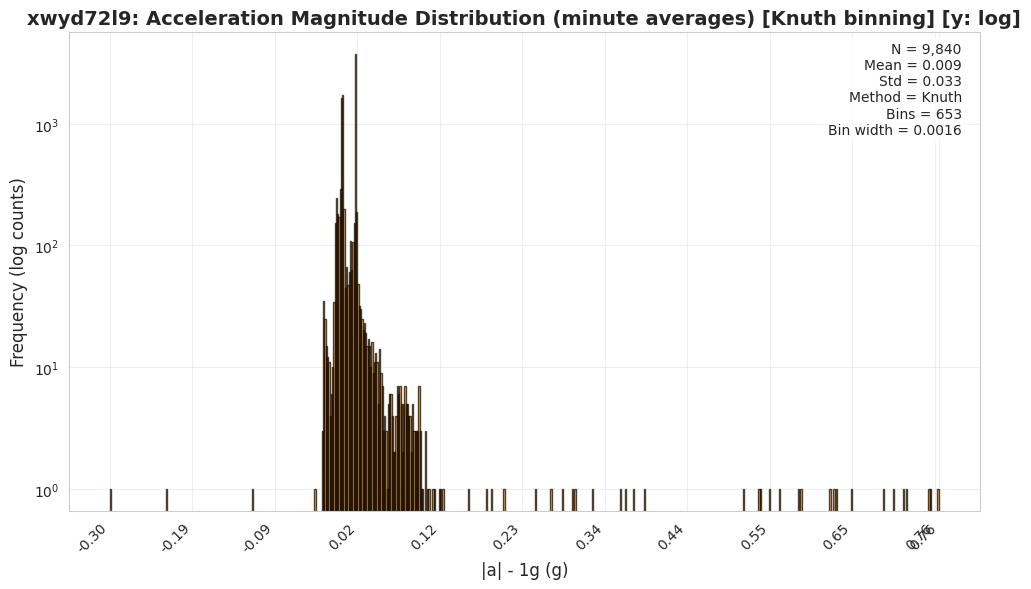


zg5uqa5l:
  Saved histogram to /n/home01/egraff/sample_imputation/plots/zg5uqa5l_knuth_magnitude_histogram.png


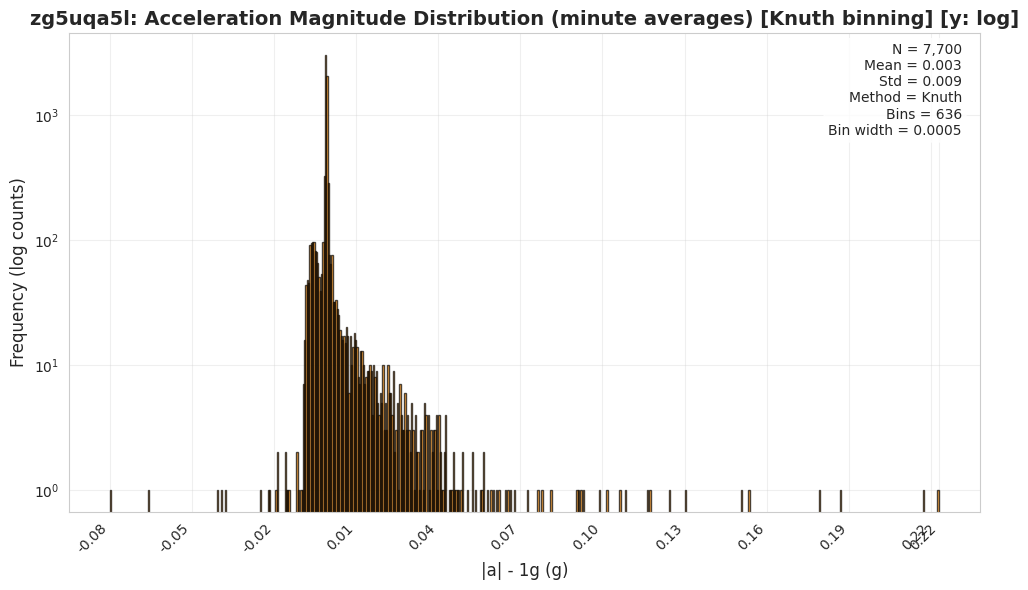


Generated Knuth-binned magnitude histograms for 6 subjects
Saved to: /n/home01/egraff/sample_imputation/plots


In [ ]:
# Generate Knuth-binned magnitude histograms for all subjects (minutely resolution)
print("Generating magnitude histograms using Knuth's optimal binning...")
print("="*70)

for subject_id in SUBJECT_IDS:
    print(f"\n{subject_id}:")
    save_path = PLOTS_DIR / f"{subject_id}_knuth_magnitude_histogram.png"
    fig = plot_knuth_histogram(
        processed_data[subject_id],
        subject_id,
        log_counts=True,
        resolution='minute',
        resolution_count=1,
        save_path=save_path
    )
    plt.show()
    plt.close(fig)

print(f"\n{'='*70}")
print(f"Generated Knuth-binned magnitude histograms for {len(SUBJECT_IDS)} subjects")
print(f"Saved to: {PLOTS_DIR}")
print(f"{'='*70}")


In [ ]:
# # TODO 
# - compare different binning methods 
# - Zoom into modes 

SyntaxError: invalid syntax (1492323834.py, line 2)